# US–JP Sector ETF Lead-Lag Strategy
## Subspace-Regularized PCA Signal (Variable-Universe Implementation)

This notebook implements a lead-lag trading strategy that:

1. Uses **US sector ETF close-to-close returns** as the information set
2. Predicts **Japanese sector ETF next-day open-to-close returns**
3. Constructs a signal via **subspace-regularized PCA** with a prior subspace $V_0$
4. Uses a **variable universe** — only tickers with sufficient data participate in PCA at each time step
5. Builds a **long-short portfolio** with strict NaN-return handling
6. Compares against baseline strategies (MOM, PCA_PLAIN, DOUBLE)

### Notebook Structure
| # | Section | Description |
|---|---------|-------------|
| 1 | Imports & Config | Libraries, ticker lists, hyper-parameters, universe config |
| 2 | Data Download | yfinance download with error handling |
| 3 | Adjusted Prices | Back-adjustment factor for open prices |
| 4 | Return Computation | close-to-close and open-to-close returns |
| 5 | Date Alignment | Careful US→JP date mapping (no look-ahead) |
| 6 | Aligned Matrices | Including strict/dynamic backtest start determination |
| 7 | Rolling Standardization | z-scores with rolling window |
| 8 | Prior Subspace $V_0$ | 3-vector Gram-Schmidt construction |
| 9 | Long-run Correlation $C_0$ | With diagnostics for XLC/XLRE |
| 10 | Rolling PCA Signal | Variable-universe regularized PCA |
| 11 | Portfolio Construction | With NaN-return re-normalisation |
| 12 | Baseline Strategies | MOM, PCA_PLAIN, DOUBLE (strict exposure) |
| 13 | Evaluation | Strict + Dynamic comparison tables |
| 14 | Plots | Cumulative returns, annual compounded returns |
| 15 | Diagnostics | Universe size, missing data, reproducibility |
| 16 | Look-Ahead Bias Check | Verification cells |


## 1. Imports

In [1]:
from __future__ import annotations
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.linalg import eigh
from typing import Dict, Tuple, Optional, List
import yfinance as yf
import datetime

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("All imports successful.")

All imports successful.


## 2. Configuration

All hyper-parameters and ticker lists in one place.

In [35]:
# ── Ticker lists ──────────────────────────────────────────────
US_TICKERS: List[str] = [
    "XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY", "XLC", "XLRE",
]

JP_TICKERS: List[str] = [
    "1617.T", "1618.T", "1619.T", "1620.T", "1621.T", "1622.T", "1623.T", "1624.T",
    "1625.T", "1626.T", "1627.T", "1628.T", "1629.T", "1630.T", "1631.T", "1632.T",
    "1633.T",
]

JP_SECTOR_NAMES: Dict[str, str] = {
    "1617.T": "食品",
    "1618.T": "エネルギー資源",
    "1619.T": "建設・資材",
    "1620.T": "素材・化学",
    "1621.T": "医薬品",
    "1622.T": "自動車・輸送機",
    "1623.T": "鉄鋼・非鉄",
    "1624.T": "機械",
    "1625.T": "電機・精密",
    "1626.T": "情報通信・サービスその他",
    "1627.T": "電気・ガス",
    "1628.T": "運輸・物流",
    "1629.T": "商社・卸売",
    "1630.T": "小売",
    "1631.T": "銀行",
    "1632.T": "金融(除く銀行)",
    "1633.T": "不動産",
}

ALL_TICKERS: List[str] = US_TICKERS + JP_TICKERS
N_US: int = len(US_TICKERS)
N_JP: int = len(JP_TICKERS)
N_ALL: int = N_US + N_JP

# ── Hyper-parameters ─────────────────────────────────────────
L: int = 60          # rolling window length (business days)
K: int = 3           # number of PCA factors retained
K0: int = 3          # prior subspace dimension
LAMBDA_: float = 0.9 # regularisation weight
Q: float = 0.3       # long/short selection quantile

# ── Date range ───────────────────────────────────────────────
DATA_START: str = "2010-01-01"
DATA_END: str = "2026-03-19"
C0_EST_START: str = "2010-01-01"
C0_EST_END: str = "2014-12-31"

# ── Cyclical / Defensive labels ──────────────────────────────
US_CYCLICAL: List[str] = ["XLB", "XLE", "XLF", "XLRE"]
US_DEFENSIVE: List[str] = ["XLK", "XLP", "XLU", "XLV"]
JP_CYCLICAL: List[str] = ["1618.T", "1625.T", "1629.T", "1631.T"]
JP_DEFENSIVE: List[str] = ["1617.T", "1621.T", "1627.T", "1630.T"]

# ── Transaction cost ──────────────────────────────────────────
COST_BPS_LIST: List[int] = [0, 5, 10, 20]  # one-way cost in basis points

# ── Universe configuration (for C0 estimation) ───────────────
# XLC listed ~Jun 2018, XLRE listed ~Oct 2015.
# These have insufficient data in the 2010-2014 C0 estimation window.
EXCLUDE_LATE_FROM_C0: bool = False  # True → estimate D0 excluding late tickers
LATE_TICKERS: List[str] = ["XLC", "XLRE"]
MIN_OBS_C0: int = 100  # min non-NaN z-scores for a ticker in C0 estimation period

print(f"US tickers: {N_US}, JP tickers: {N_JP}, Total: {N_ALL}")
print(f"Rolling window L={L}, Factors K={K}, lambda={LAMBDA_}, quantile q={Q}")
print(f"EXCLUDE_LATE_FROM_C0={EXCLUDE_LATE_FROM_C0}, LATE_TICKERS={LATE_TICKERS}")


US tickers: 11, JP tickers: 17, Total: 28
Rolling window L=60, Factors K=3, lambda=0.9, quantile q=0.3
EXCLUDE_LATE_FROM_C0=False, LATE_TICKERS=['XLC', 'XLRE']


## 3. Data Download

Download OHLCV data via `yfinance`.  US and JP are downloaded separately to handle different trading calendars.

In [3]:
def download_data(
    tickers: List[str],
    start: str,
    end: str,
    group_label: str = "",
) -> Dict[str, pd.DataFrame]:
    """Download OHLCV data from yfinance for a list of tickers.

    Returns a dict  ticker -> DataFrame with columns [Open, High, Low, Close, Adj Close, Volume].
    Missing tickers are reported but not fatal.
    """
    print(f"Downloading {group_label} ({len(tickers)} tickers) from {start} to {end} ...")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=False, actions=False)

    # yfinance returns MultiIndex columns (field, ticker) when len(tickers) > 1
    result: Dict[str, pd.DataFrame] = {}
    for tk in tickers:
        try:
            if len(tickers) == 1:
                df = raw.copy()
            else:
                df = raw.xs(tk, level="Ticker", axis=1)
            # Drop rows where Close is NaN (non-trading days for this ticker)
            df = df.dropna(subset=["Close"])
            if len(df) == 0:
                print(f"  WARNING: {tk} has no data.")
                continue
            result[tk] = df
            print(f"  {tk}: {len(df)} rows, {df.index[0].date()} – {df.index[-1].date()}")
        except Exception as e:
            print(f"  WARNING: {tk} failed – {e}")
    return result


us_data = download_data(US_TICKERS, DATA_START, DATA_END, "US sectors")
jp_data = download_data(JP_TICKERS, DATA_START, DATA_END, "JP sectors")

[*********************100%***********************]  11 of 11 completed
[                       0%                       ]

  XLB: 4076 rows, 2010-01-04 – 2026-03-18
  XLE: 4076 rows, 2010-01-04 – 2026-03-18
  XLF: 4076 rows, 2010-01-04 – 2026-03-18
  XLI: 4076 rows, 2010-01-04 – 2026-03-18
  XLK: 4076 rows, 2010-01-04 – 2026-03-18
  XLP: 4076 rows, 2010-01-04 – 2026-03-18
  XLU: 4076 rows, 2010-01-04 – 2026-03-18
  XLV: 4076 rows, 2010-01-04 – 2026-03-18
  XLY: 4076 rows, 2010-01-04 – 2026-03-18
  XLC: 1947 rows, 2018-06-19 – 2026-03-18
  XLRE: 2625 rows, 2015-10-08 – 2026-03-18


[*********************100%***********************]  17 of 17 completed

  1617.T: 3982 rows, 2010-01-04 – 2026-03-18
  1618.T: 3982 rows, 2010-01-04 – 2026-03-18
  1619.T: 3982 rows, 2010-01-04 – 2026-03-18
  1620.T: 3982 rows, 2010-01-04 – 2026-03-18
  1621.T: 3982 rows, 2010-01-04 – 2026-03-18
  1622.T: 3982 rows, 2010-01-04 – 2026-03-18
  1623.T: 3982 rows, 2010-01-04 – 2026-03-18
  1624.T: 3982 rows, 2010-01-04 – 2026-03-18
  1625.T: 3982 rows, 2010-01-04 – 2026-03-18
  1626.T: 3982 rows, 2010-01-04 – 2026-03-18
  1627.T: 3982 rows, 2010-01-04 – 2026-03-18
  1628.T: 3982 rows, 2010-01-04 – 2026-03-18
  1629.T: 3982 rows, 2010-01-04 – 2026-03-18
  1630.T: 3982 rows, 2010-01-04 – 2026-03-18
  1631.T: 3982 rows, 2010-01-04 – 2026-03-18
  1632.T: 3982 rows, 2010-01-04 – 2026-03-18
  1633.T: 3982 rows, 2010-01-04 – 2026-03-18


## 4. Adjusted Prices

Compute `adj_open` and `adj_close` using the back-adjustment factor:
$$\text{factor}_t = \frac{\text{Adj Close}_t}{\text{Close}_t}, \qquad
\text{adj\_open}_t = \text{Open}_t \times \text{factor}_t, \qquad
\text{adj\_close}_t = \text{Adj Close}_t$$

In [4]:
def make_adjusted_open_close(
    data: Dict[str, pd.DataFrame],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Build adj_open and adj_close DataFrames from raw OHLCV dicts.

    Returns
    -------
    adj_open : DataFrame (date x ticker)
    adj_close : DataFrame (date x ticker)
    """
    adj_open_dict: Dict[str, pd.Series] = {}
    adj_close_dict: Dict[str, pd.Series] = {}
    for tk, df in data.items():
        factor = df["Adj Close"] / df["Close"]
        adj_open_dict[tk] = df["Open"] * factor
        adj_close_dict[tk] = df["Adj Close"]
    adj_open = pd.DataFrame(adj_open_dict)
    adj_close = pd.DataFrame(adj_close_dict)
    return adj_open, adj_close


us_adj_open, us_adj_close = make_adjusted_open_close(us_data)
jp_adj_open, jp_adj_close = make_adjusted_open_close(jp_data)

print(f"US adj_close shape: {us_adj_close.shape}  ({us_adj_close.index[0].date()} – {us_adj_close.index[-1].date()})")
print(f"JP adj_close shape: {jp_adj_close.shape}  ({jp_adj_close.index[0].date()} – {jp_adj_close.index[-1].date()})")

US adj_close shape: (4076, 11)  (2010-01-04 – 2026-03-18)
JP adj_close shape: (3982, 17)  (2010-01-04 – 2026-03-18)


## 5. Return Computation

- **Close-to-close (cc)**: $r^{cc}_{i,t} = P^{close}_{i,t} / P^{close}_{i,t-1} - 1$
- **Open-to-close (oc)**: $r^{oc}_{j,t} = P^{close}_{j,t} / P^{open}_{j,t} - 1$

No forward-fill is applied.  Only actual trading dates with non-NaN prices are used.

In [5]:
def compute_returns(
    adj_open: pd.DataFrame,
    adj_close: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Compute close-to-close and open-to-close returns.

    Returns
    -------
    r_cc : DataFrame  close-to-close simple return (pct_change of adj_close)
    r_oc : DataFrame  open-to-close simple return
    """
    # close-to-close: adj_close[t] / adj_close[t-1] - 1
    r_cc = adj_close.pct_change()  # first row becomes NaN

    # open-to-close: adj_close[t] / adj_open[t] - 1
    r_oc = adj_close / adj_open - 1

    return r_cc, r_oc


us_r_cc, us_r_oc = compute_returns(us_adj_open, us_adj_close)
jp_r_cc, jp_r_oc = compute_returns(jp_adj_open, jp_adj_close)

print("US r_cc shape:", us_r_cc.shape, " | non-NaN frac:", us_r_cc.notna().mean().mean().round(3))
print("JP r_cc shape:", jp_r_cc.shape, " | non-NaN frac:", jp_r_cc.notna().mean().mean().round(3))
print("JP r_oc shape:", jp_r_oc.shape, " | non-NaN frac:", jp_r_oc.notna().mean().mean().round(3))

US r_cc shape: (4076, 11)  | non-NaN frac: 0.92
JP r_cc shape: (3982, 17)  | non-NaN frac: 1.0
JP r_oc shape: (3982, 17)  | non-NaN frac: 1.0


## 6. Date Alignment (US → JP)

**Key logic — no look-ahead:**

We need to pair each US trading day $t$ with the **next** JP trading day $t'$ such that:
- The US market has closed (US close → ~16:00 ET)
- The JP market has **not yet opened** (JP open → ~09:00 JST the next calendar day)
- Therefore for each US date $d_{US}$, we find the first JP trading date $d_{JP} > d_{US}$

This ensures the US close-to-close return on day $d_{US}$ is known **before** the JP open on $d_{JP}$.

We also construct a combined date-pair index and
align all returns to that index.  **No forward-fill** is applied.

In [6]:
def align_us_jp_dates(
    us_dates: pd.DatetimeIndex,
    jp_dates: pd.DatetimeIndex,
) -> pd.DataFrame:
    """For each US trading date, find the next JP trading date strictly after it.

    Returns a DataFrame with columns ['us_date', 'jp_date'].
    Rows where no valid JP date exists are dropped.

    Logic
    -----
    For each us_date d:
        jp_date = first element of jp_dates where jp_dates > d
    This is equivalent to searchsorted(d, side='right').

    Because JP is ~14 h ahead of US East Coast:
    - US closes Mon 16:00 ET → JP opens Tue 09:00 JST  (same calendar Tue)
    - US closes Fri 16:00 ET → JP opens Mon 09:00 JST
    So "strictly after" in calendar date terms captures the correct sequence.
    """
    jp_sorted = jp_dates.sort_values()
    pairs = []
    for d in us_dates:
        idx = jp_sorted.searchsorted(d, side="right")
        if idx < len(jp_sorted):
            pairs.append((d, jp_sorted[idx]))
    date_map = pd.DataFrame(pairs, columns=["us_date", "jp_date"])
    # Sanity: no duplicate JP dates (a JP date can correspond to at most one US date).
    # If US has Mon and Tue (JP holiday on Tue), both map to JP Wed → keep only latest US date.
    date_map = date_map.drop_duplicates(subset="jp_date", keep="last")
    return date_map.reset_index(drop=True)


date_map = align_us_jp_dates(us_r_cc.index, jp_r_cc.index)
print(f"Aligned date pairs: {len(date_map)}")
print(date_map.head(10))
print("...")
print(date_map.tail(5))

Aligned date pairs: 3844
     us_date    jp_date
0 2010-01-04 2010-01-05
1 2010-01-05 2010-01-06
2 2010-01-06 2010-01-07
3 2010-01-07 2010-01-08
4 2010-01-11 2010-01-12
5 2010-01-12 2010-01-13
6 2010-01-13 2010-01-14
7 2010-01-14 2010-01-15
8 2010-01-15 2010-01-18
9 2010-01-19 2010-01-20
...
        us_date    jp_date
3839 2026-03-11 2026-03-12
3840 2026-03-12 2026-03-13
3841 2026-03-13 2026-03-16
3842 2026-03-16 2026-03-17
3843 2026-03-17 2026-03-18


## 7. Build Aligned Return Matrices

For each date-pair $(d_{US}, d_{JP})$ we collect:
- `us_cc[t]` = US close-to-close return on $d_{US}$
- `jp_cc[t]` = JP close-to-close return on $d_{JP}$ ← used for rolling correlation estimation
- `jp_oc[t]` = JP open-to-close return on $d_{JP}$ ← used for PnL

The combined close-to-close matrix (US ∪ JP) is used to estimate the rolling correlation matrix.

In [20]:
# Build aligned return matrices indexed by a sequential "pair index" t = 0, 1, 2, ...
# To avoid any confusion, we keep the date_map as the authoritative mapping.

# US close-to-close returns aligned to us_date
aligned_us_cc = us_r_cc.loc[date_map["us_date"].values].copy()
aligned_us_cc.index = date_map.index  # integer pair index

# JP close-to-close returns aligned to jp_date
aligned_jp_cc = jp_r_cc.loc[date_map["jp_date"].values].copy()
aligned_jp_cc.index = date_map.index

# JP open-to-close returns aligned to jp_date (for PnL)
aligned_jp_oc = jp_r_oc.loc[date_map["jp_date"].values].copy()
aligned_jp_oc.index = date_map.index

# Combined close-to-close matrix: [US tickers || JP tickers] x T
# Column order = US_TICKERS + JP_TICKERS (same as ALL_TICKERS)
available_us = [t for t in US_TICKERS if t in aligned_us_cc.columns]
available_jp = [t for t in JP_TICKERS if t in aligned_jp_cc.columns]
combined_cc = pd.concat(
    [aligned_us_cc[available_us], aligned_jp_cc[available_jp]],
    axis=1,
)
combined_tickers = list(combined_cc.columns)

print(f"Combined cc matrix shape: {combined_cc.shape}")
print(f"Available US: {len(available_us)}, Available JP: {len(available_jp)}")
print(f"Date range: US {date_map['us_date'].iloc[0].date()} – {date_map['us_date'].iloc[-1].date()}")
print(f"           JP {date_map['jp_date'].iloc[0].date()} – {date_map['jp_date'].iloc[-1].date()}")


# ══════════════════════════════════════════════════════════════════════════════
# Helper functions
# ══════════════════════════════════════════════════════════════════════════════

def find_first_valid_dates(
    cc: pd.DataFrame,
    dmap: pd.DataFrame,
) -> pd.DataFrame:
    """Find the first pair_idx where each ticker has a non-NaN return.

    Returns DataFrame indexed by ticker with columns
    [first_pair_idx, us_date, jp_date].
    """
    rows = []
    for col in cc.columns:
        valid_idx = cc[col].first_valid_index()
        if valid_idx is not None:
            rows.append({
                "ticker": col,
                "first_pair_idx": int(valid_idx),
                "us_date": dmap.loc[valid_idx, "us_date"],
                "jp_date": dmap.loc[valid_idx, "jp_date"],
            })
        else:
            rows.append({
                "ticker": col, "first_pair_idx": None,
                "us_date": pd.NaT, "jp_date": pd.NaT,
            })
    return pd.DataFrame(rows).set_index("ticker")


def determine_backtest_starts(
    valid_counts_df: pd.DataFrame,
    dmap: pd.DataFrame,
    n_us: int,
    n_jp: int,
    K_min: int,
) -> Dict[str, Dict]:
    """Determine strict and dynamic backtest starts from valid_counts_df.

    Uses the z-score-based valid universe counts produced by
    rolling_subspace_pca_signal(), ensuring perfect alignment with
    PCA's actual validity logic.

    Parameters
    ----------
    valid_counts_df : DataFrame with columns [valid_us, valid_jp, valid_total]
        Index = pair_idx.  Produced by rolling_subspace_pca_signal().
    dmap : DataFrame  date-pair mapping
    n_us : int  number of US tickers in full universe
    n_jp : int  number of JP tickers in full universe
    K_min : int  minimum valid US / JP for dynamic start

    Returns
    -------
    dict with keys 'strict' and/or 'dynamic', each containing
    {'pair_idx': int, 'us_date': Timestamp, 'jp_date': Timestamp}.
    """
    results: Dict[str, Dict] = {}

    # Dynamic: first pair_idx where valid_us >= K_min AND valid_jp >= K_min
    dyn_mask = (
        (valid_counts_df["valid_us"] >= K_min) &
        (valid_counts_df["valid_jp"] >= K_min)
    )
    if dyn_mask.any():
        idx = int(valid_counts_df.loc[dyn_mask].index[0])
        results["dynamic"] = {
            "pair_idx": idx,
            "us_date": dmap.loc[idx, "us_date"],
            "jp_date": dmap.loc[idx, "jp_date"],
        }

    # Strict: first pair_idx where valid_us == n_us AND valid_jp == n_jp
    strict_mask = (
        (valid_counts_df["valid_us"] == n_us) &
        (valid_counts_df["valid_jp"] == n_jp)
    )
    if strict_mask.any():
        idx = int(valid_counts_df.loc[strict_mask].index[0])
        results["strict"] = {
            "pair_idx": idx,
            "us_date": dmap.loc[idx, "us_date"],
            "jp_date": dmap.loc[idx, "jp_date"],
        }

    return results


# ── First valid dates per ticker ─────────────────────────────────────────────
first_valid_df = find_first_valid_dates(combined_cc, date_map)
print("\n── First valid dates per ticker ──")
for tk in combined_tickers:
    row = first_valid_df.loc[tk]
    label = " ← LATE" if tk in LATE_TICKERS else ""
    if pd.notna(row["us_date"]):
        print(f"  {tk:8s} : pair_idx={int(row['first_pair_idx']):5d}, "
              f"us_date={row['us_date'].strftime('%Y-%m-%d')}, "
              f"jp_date={row['jp_date'].strftime('%Y-%m-%d')}{label}")
    else:
        print(f"  {tk:8s} : NO VALID DATA{label}")

# ── Preliminary dynamic start (cc-based, to seed PCA signal computation) ─────
# This is a conservative lower bound: the definitive starts are derived later
# from valid_counts_df produced by rolling_subspace_pca_signal().
after_c0_mask = date_map["us_date"] > pd.Timestamp(C0_EST_END)
first_after_c0 = int(date_map.loc[after_c0_mask].index[0])
bt_start_dynamic_prelim = max(first_after_c0, L)

print(f"\n── Preliminary Backtest Start (cc-based, for PCA seed) ──")
print(f"  first_after_c0       = {first_after_c0}")
print(f"  bt_start_dynamic_prelim = {bt_start_dynamic_prelim}")
print(f"  (Definitive starts will be derived from valid_counts after PCA runs.)")


Combined cc matrix shape: (3844, 28)
Available US: 11, Available JP: 17
Date range: US 2010-01-04 – 2026-03-17
           JP 2010-01-05 – 2026-03-18

── First valid dates per ticker ──
  XLB      : pair_idx=    1, us_date=2010-01-05, jp_date=2010-01-06
  XLE      : pair_idx=    1, us_date=2010-01-05, jp_date=2010-01-06
  XLF      : pair_idx=    1, us_date=2010-01-05, jp_date=2010-01-06
  XLI      : pair_idx=    1, us_date=2010-01-05, jp_date=2010-01-06
  XLK      : pair_idx=    1, us_date=2010-01-05, jp_date=2010-01-06
  XLP      : pair_idx=    1, us_date=2010-01-05, jp_date=2010-01-06
  XLU      : pair_idx=    1, us_date=2010-01-05, jp_date=2010-01-06
  XLV      : pair_idx=    1, us_date=2010-01-05, jp_date=2010-01-06
  XLY      : pair_idx=    1, us_date=2010-01-05, jp_date=2010-01-06
  XLC      : pair_idx= 2018, us_date=2018-06-20, jp_date=2018-06-21 ← LATE
  XLRE     : pair_idx= 1367, us_date=2015-10-12, jp_date=2015-10-13 ← LATE
  1617.T   : pair_idx=    0, us_date=2010-01-04, jp_d

## 8. Rolling Standardization

For each pair-index $t$ and asset $i$:
$$\mu_{i,t} = \frac{1}{L}\sum_{\tau=t-L}^{t-1} r^{cc}_{i,\tau}, \qquad
\sigma_{i,t} = \text{std}\bigl(\{r^{cc}_{i,\tau}\}_{\tau=t-L}^{t-1}\bigr)$$
$$z_{i,t} = \frac{r^{cc}_{i,t} - \mu_{i,t}}{\sigma_{i,t}}$$

The window uses **strictly past** data ($t-L$ to $t-1$) to avoid look-ahead.

In [21]:
def rolling_standardize(
    r_cc: pd.DataFrame,
    window: int,
) -> pd.DataFrame:
    """Standardize close-to-close returns using a strictly backward-looking rolling window.

    For each time t, mu and sigma are computed from rows [t-window, t-1].
    z[t] = (r_cc[t] - mu[t]) / sigma[t].

    Parameters
    ----------
    r_cc : DataFrame (T x N)
    window : int  rolling window length

    Returns
    -------
    z : DataFrame (T x N)  standardized returns; first `window` rows are NaN.
    """
    # .rolling(window).mean() at index t uses rows [t-window+1 .. t].
    # We need [t-window .. t-1], so shift by 1.
    roll_mean = r_cc.rolling(window=window, min_periods=window).mean().shift(1)
    roll_std = r_cc.rolling(window=window, min_periods=window).std(ddof=1).shift(1)

    # Avoid division by zero
    roll_std = roll_std.replace(0.0, np.nan)

    z = (r_cc - roll_mean) / roll_std
    return z


z_combined = rolling_standardize(combined_cc, L)

# Also build separate US and JP z-scores for convenience
z_us = z_combined[available_us]
z_jp = z_combined[available_jp]

print(f"z_combined shape: {z_combined.shape}")
print(f"First valid row (all non-NaN for available):")
first_full = z_combined.dropna(how="any").index[0] if len(z_combined.dropna(how="any")) > 0 else "none"
print(f"  pair index = {first_full}")

z_combined shape: (3844, 28)
First valid row (all non-NaN for available):
  pair index = 2078


## 9. Prior Subspace $V_0$

Three directions ($K_0 = 3$), Gram-Schmidt orthogonalized:

1. **Global factor** $v_1 \propto \mathbf{1}$
2. **Country spread** US = +1, JP = −1, orthogonalized to $v_1$
3. **Cyclical vs Defensive** cyclical = +1, defensive = −1, others = 0, orthogonalized to $v_1, v_2$

In [22]:
def build_prior_subspace(
    tickers: List[str],
    n_us: int,
    us_cyclical: List[str],
    us_defensive: List[str],
    jp_cyclical: List[str],
    jp_defensive: List[str],
) -> np.ndarray:
    """Build the K0=3 prior subspace V0 via Gram-Schmidt.

    Parameters
    ----------
    tickers : list of str  ordered ticker list [US ... JP]
    n_us : int  number of US tickers (first n_us entries are US)

    Returns
    -------
    V0 : ndarray (N x K0)  orthonormal columns
    """
    N = len(tickers)
    n_jp = N - n_us
    ticker_to_idx = {t: i for i, t in enumerate(tickers)}

    # --- v1: global factor (all ones, normalised) ---
    v1 = np.ones(N)

    # --- v2_raw: country spread US=+1, JP=-1 ---
    v2_raw = np.zeros(N)
    v2_raw[:n_us] = 1.0
    v2_raw[n_us:] = -1.0

    # --- v3_raw: cyclical=+1, defensive=-1, others=0 ---
    v3_raw = np.zeros(N)
    for t in us_cyclical + jp_cyclical:
        if t in ticker_to_idx:
            v3_raw[ticker_to_idx[t]] = 1.0
    for t in us_defensive + jp_defensive:
        if t in ticker_to_idx:
            v3_raw[ticker_to_idx[t]] = -1.0

    # ── Gram-Schmidt orthogonalization ──
    def normalize(v: np.ndarray) -> np.ndarray:
        n = np.linalg.norm(v)
        assert n > 1e-12, "Zero vector in Gram-Schmidt"
        return v / n

    e1 = normalize(v1)

    v2_orth = v2_raw - np.dot(v2_raw, e1) * e1
    e2 = normalize(v2_orth)

    v3_orth = v3_raw - np.dot(v3_raw, e1) * e1 - np.dot(v3_raw, e2) * e2
    e3 = normalize(v3_orth)

    V0 = np.column_stack([e1, e2, e3])

    # Verify orthonormality
    gram = V0.T @ V0
    assert np.allclose(gram, np.eye(K0), atol=1e-10), f"V0 not orthonormal: {gram}"
    return V0


V0 = build_prior_subspace(
    combined_tickers,
    len(available_us),
    US_CYCLICAL, US_DEFENSIVE,
    JP_CYCLICAL, JP_DEFENSIVE,
)
print(f"V0 shape: {V0.shape}")
print("V0.T @ V0 =")
print(np.round(V0.T @ V0, 6))

V0 shape: (28, 3)
V0.T @ V0 =
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]


## 10. Long-Run Prior Correlation $C_0$

Estimate $C_{\text{full}}$ from 2010-01-01 to 2014-12-31, then project onto $V_0$:
$$D_0 = \text{diag}\bigl(V_0^\top C_{\text{full}} V_0\bigr)$$
$$C_0^{\text{raw}} = V_0 \, D_0 \, V_0^\top$$
Normalise so that $\text{diag}(C_0) = \mathbf{1}$.

In [23]:
def estimate_C0(
    z: pd.DataFrame,
    date_map: pd.DataFrame,
    est_start: str,
    est_end: str,
    V0: np.ndarray,
    tickers: List[str],
    min_obs: int = 100,
    exclude_tickers: Optional[List[str]] = None,
) -> np.ndarray:
    """Estimate prior correlation C0 from the estimation window with diagnostics.

    Steps
    -----
    1. Select pair-indices where us_date ∈ [est_start, est_end]
    2. Report per-asset observation counts (flag insufficient data)
    3. Compute sample correlation C_full; report NaN fraction
    4. If exclude_tickers, estimate D0 from sufficient-data rows of V0 only
    5. Project: C0_raw = V0 @ D0 @ V0.T  (always full-dimension output)
    6. Normalize diagonal to 1

    Parameters
    ----------
    z : DataFrame  combined standardized returns
    date_map : DataFrame  date-pair mapping
    est_start, est_end : str  estimation window boundaries
    V0 : ndarray (N x K0)  prior subspace
    tickers : list of str  column ordering matching V0 / C0 rows
    min_obs : int  minimum observations to consider a ticker reliable
    exclude_tickers : list of str or None  tickers to exclude from D0 estimation

    Returns
    -------
    C0 : ndarray (N x N)
    """
    mask = (date_map["us_date"] >= est_start) & (date_map["us_date"] <= est_end)
    est_idx = date_map.loc[mask].index
    z_est = z.loc[est_idx].dropna(how="all")
    N = len(tickers)

    # ── Per-asset observation diagnostics ─────────────────────────────────────
    obs_counts = z_est[tickers].notna().sum()
    print(f"C0 estimation period: {est_start} to {est_end}")
    print(f"Total pair indices in period: {len(est_idx)}")
    print(f"\nPer-asset observations (non-NaN z-scores):")
    for tk in tickers:
        count = int(obs_counts.get(tk, 0))
        flag = " *** INSUFFICIENT" if count < min_obs else ""
        late = " (LATE LISTING)" if exclude_tickers and tk in exclude_tickers else ""
        print(f"  {tk:8s}: {count:5d} obs{flag}{late}")

    # ── Compute C_full (pairwise correlation) ─────────────────────────────────
    C_full = z_est[tickers].corr().values

    # Report NaN fraction
    total_elements = N * N
    nan_count = int(np.isnan(C_full).sum())
    nan_frac = nan_count / total_elements
    print(f"\nC_full shape: {C_full.shape}")
    print(f"C_full NaN entries: {nan_count} / {total_elements} ({nan_frac:.4f})")

    if nan_count > 0:
        nan_pairs = []
        for i in range(N):
            for j in range(i + 1, N):
                if np.isnan(C_full[i, j]):
                    nan_pairs.append((tickers[i], tickers[j]))
        if len(nan_pairs) <= 20:
            print(f"  NaN ticker pairs: {nan_pairs}")
        else:
            print(f"  NaN ticker pairs (first 20): {nan_pairs[:20]} ...")

    # ── Determine which tickers to use for D0 estimation ─────────────────────
    if exclude_tickers:
        use_idx = [i for i, tk in enumerate(tickers) if tk not in exclude_tickers]
        excluded = [tk for tk in tickers if tk in exclude_tickers]
        print(f"\nExcluding from D0 estimation: {excluded}")
        print(f"Using {len(use_idx)} / {N} tickers for D0")
    else:
        use_idx = list(range(N))

    # Fill NaN in C_full with 0 (only for projection; documented above)
    C_full_clean = np.nan_to_num(C_full, nan=0.0)
    np.fill_diagonal(C_full_clean, 1.0)

    # ── Project onto prior subspace ──────────────────────────────────────────
    if len(use_idx) < N:
        # Reduced estimation: D0 from subset rows of V0
        V0_S = V0[use_idx, :]                              # (n_valid x K0)
        C_S = C_full_clean[np.ix_(use_idx, use_idx)]       # (n_valid x n_valid)
        D0 = np.diag(np.diag(V0_S.T @ C_S @ V0_S))        # (K0 x K0)
    else:
        D0 = np.diag(np.diag(V0.T @ C_full_clean @ V0))   # (K0 x K0)

    C0_raw = V0 @ D0 @ V0.T                                # (N x N)

    # Normalize so that diag(C0) = 1
    d = np.sqrt(np.diag(C0_raw))
    d[d < 1e-12] = 1.0
    D_inv = np.diag(1.0 / d)
    C0 = D_inv @ C0_raw @ D_inv
    np.fill_diagonal(C0, 1.0)

    # ── Assertions ───────────────────────────────────────────────────────────
    assert C0.shape == (N, N), f"C0 shape {C0.shape} != ({N},{N})"
    assert np.allclose(np.diag(C0), 1.0), "diag(C0) != 1"
    assert np.allclose(C0, C0.T), "C0 not symmetric"
    assert np.all(np.isfinite(C0)), "C0 contains non-finite values"

    print(f"\n✓ C0 assertions passed: shape=({N},{N}), symmetric, diag=1, all finite")
    return C0


# ── Estimate BOTH C0 variants for comparison (Fix 2) ─────────────────────────
print("=" * 70)
print("C0_full: include ALL tickers (late tickers → 0 obs → NaN→0 in C_full)")
print("=" * 70)
C0_full = estimate_C0(
    z_combined, date_map, C0_EST_START, C0_EST_END, V0,
    combined_tickers,
    min_obs=MIN_OBS_C0,
    exclude_tickers=None,
)
print(f"\nC0_full off-diag range: [{C0_full[~np.eye(C0_full.shape[0], dtype=bool)].min():.4f}, "
      f"{C0_full[~np.eye(C0_full.shape[0], dtype=bool)].max():.4f}]")

print("\n" + "=" * 70)
print("C0_reduced: exclude LATE_TICKERS from D0 estimation")
print("=" * 70)
C0_reduced = estimate_C0(
    z_combined, date_map, C0_EST_START, C0_EST_END, V0,
    combined_tickers,
    min_obs=MIN_OBS_C0,
    exclude_tickers=LATE_TICKERS,
)
print(f"\nC0_reduced off-diag range: [{C0_reduced[~np.eye(C0_reduced.shape[0], dtype=bool)].min():.4f}, "
      f"{C0_reduced[~np.eye(C0_reduced.shape[0], dtype=bool)].max():.4f}]")

# ── Compare C0_full vs C0_reduced ──────────────────────────────────────────
diff = np.abs(C0_full - C0_reduced)
print(f"\n|C0_full − C0_reduced| max={diff.max():.6f}, mean={diff.mean():.6f}")

# Default C0 for backward compatibility
C0 = C0_full


C0_full: include ALL tickers (late tickers → 0 obs → NaN→0 in C_full)
C0 estimation period: 2010-01-01 to 2014-12-31
Total pair indices in period: 1183

Per-asset observations (non-NaN z-scores):
  XLB     :  1122 obs
  XLE     :  1122 obs
  XLF     :  1122 obs
  XLI     :  1122 obs
  XLK     :  1122 obs
  XLP     :  1122 obs
  XLU     :  1122 obs
  XLV     :  1122 obs
  XLY     :  1122 obs
  XLC     :     0 obs *** INSUFFICIENT
  XLRE    :     0 obs *** INSUFFICIENT
  1617.T  :  1123 obs
  1618.T  :  1123 obs
  1619.T  :  1123 obs
  1620.T  :  1123 obs
  1621.T  :  1123 obs
  1622.T  :  1123 obs
  1623.T  :  1123 obs
  1624.T  :  1123 obs
  1625.T  :  1123 obs
  1626.T  :  1123 obs
  1627.T  :  1123 obs
  1628.T  :  1123 obs
  1629.T  :  1123 obs
  1630.T  :  1123 obs
  1631.T  :  1123 obs
  1632.T  :  1123 obs
  1633.T  :  1123 obs

C_full shape: (28, 28)
C_full NaN entries: 108 / 784 (0.1378)
  NaN ticker pairs (first 20): [('XLB', 'XLC'), ('XLB', 'XLRE'), ('XLE', 'XLC'), ('XLE', 'X

## 11. Rolling Subspace-Regularized PCA Signal

At each pair-index $t$:

1. Rolling correlation $C_t$ from $z$ over $[t-L, t-1]$
2. Regularized: $C^{reg}_t = (1-\lambda) C_t + \lambda C_0$
3. Eigen-decompose → top $K$ eigenvectors $V_t^{(K)}$
4. Split into US block $V^U_t$ and JP block $V^J_t$
5. US shock: $z^U_t$ (standardized US return at time $t$)
6. Factor scores: $f_t = (V^U_t)^\top z^U_t$
7. JP predicted z-score: $\hat{z}^J_{t+1} = V^J_t f_t$

Equivalently: $\hat{z}^J_{t+1} = B_t \, z^U_t$ where $B_t = V^J_t (V^U_t)^\top$.

In [24]:
def rolling_subspace_pca_signal(
    z: pd.DataFrame,
    us_cols: List[str],
    jp_cols: List[str],
    C0_full: np.ndarray,
    full_tickers: List[str],
    window: int,
    lambda_: float,
    K: int,
    bt_start: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Generate rolling PCA-based JP predicted z-scores with variable universe.

    At each time t, only assets with sufficient data in the rolling window
    are included.  C0 sub-matrix is extracted from C0_full for valid assets.
    No "fixed dimension + NaN filling" — the PCA dimension adapts each day.

    Parameters
    ----------
    z : DataFrame (T x N_all)  combined standardized returns
    us_cols, jp_cols : column names for US / JP
    C0_full : ndarray (N_full x N_full)  prior correlation for full universe
    full_tickers : list of str  ordered column names matching C0_full rows/cols
    window : rolling window for Ct
    lambda_ : regularization weight
    K : number of eigenvectors to retain
    bt_start : first pair-index to produce signal

    Returns
    -------
    signal_df : DataFrame (pair_index x jp_cols)
        Predicted JP z-scores. NaN for tickers not valid at that time.
    valid_counts_df : DataFrame (pair_index x [valid_us, valid_jp, valid_total])
        Universe size diagnostics per day.
    """
    all_cols = list(us_cols) + list(jp_cols)

    # Ticker → index in C0_full (for sub-matrix extraction)
    tk_to_full_idx: Dict[str, int] = {tk: i for i, tk in enumerate(full_tickers)}

    T = len(z)
    signals: Dict[int, Dict[str, float]] = {}
    universe_info: Dict[int, Dict[str, int]] = {}
    n_skipped = 0

    for t in range(bt_start, T):
        start_idx = t - window
        if start_idx < 0:
            continue

        # ── Step 1: determine valid universe at time t ──────────────────────
        z_window = z[all_cols].iloc[start_idx:t]   # rows [t-window, t-1]
        window_counts = z_window.notna().sum()

        # Valid for correlation: need full window of non-NaN z-scores
        valid_corr_us = [c for c in us_cols if window_counts[c] >= window]
        valid_corr_jp = [c for c in jp_cols if window_counts[c] >= window]

        # For US shock at time t, also need z[t] to be non-NaN
        z_t = z.iloc[t]
        valid_us_t = [c for c in valid_corr_us if pd.notna(z_t[c])]
        valid_jp_t = valid_corr_jp  # JP z[t] not needed for signal

        n_valid_us = len(valid_us_t)
        n_valid_jp = len(valid_jp_t)
        universe_info[t] = {
            "valid_us": n_valid_us,
            "valid_jp": n_valid_jp,
            "valid_total": n_valid_us + n_valid_jp,
        }

        # ── Step 2: minimum universe requirement ────────────────────────────
        if n_valid_us < K or n_valid_jp < K:
            n_skipped += 1
            signals[t] = {c: np.nan for c in jp_cols}
            continue

        # ── Step 3: build sub-matrices for valid universe ───────────────────
        valid_all = valid_us_t + valid_jp_t
        N_valid = len(valid_all)

        # Extract C0 sub-matrix
        full_indices = [tk_to_full_idx[tk] for tk in valid_all]
        C0_sub = C0_full[np.ix_(full_indices, full_indices)]

        # Rolling correlation from valid columns only (no NaN filling
        # for absent assets — they simply don't participate)
        z_window_valid = z_window[valid_all]
        Ct = z_window_valid.corr().values

        # Fill remaining NaN in Ct (within valid universe) with C0_sub
        nan_mask = np.isnan(Ct)
        if nan_mask.any():
            Ct[nan_mask] = C0_sub[nan_mask]
        np.fill_diagonal(Ct, 1.0)

        # ── Step 4: regularize ──────────────────────────────────────────────
        C_reg = (1.0 - lambda_) * Ct + lambda_ * C0_sub
        C_reg = 0.5 * (C_reg + C_reg.T)
        np.fill_diagonal(C_reg, 1.0)

        # ── Step 5: eigen-decomposition (top K eigenvectors) ────────────────
        eigvals, eigvecs = eigh(C_reg)
        V_K = eigvecs[:, -K:][:, ::-1]  # sorted descending by eigenvalue

        # ── Step 6: split into US and JP blocks ─────────────────────────────
        VU = V_K[:n_valid_us, :]   # (n_valid_us x K)
        VJ = V_K[n_valid_us:, :]   # (n_valid_jp x K)

        # ── Step 7: US shock — only valid US tickers, no NaN→0 ─────────────
        zU_t = z_t[valid_us_t].values  # all non-NaN by construction

        # ── Step 8: factor scores and JP prediction ─────────────────────────
        f_t = VU.T @ zU_t
        zhat_J = VJ @ f_t

        # ── Step 9: store signal — NaN for non-valid JP tickers ─────────────
        sig_dict: Dict[str, float] = {c: np.nan for c in jp_cols}
        for i, jp_tk in enumerate(valid_jp_t):
            sig_dict[jp_tk] = float(zhat_J[i])
        signals[t] = sig_dict

    if n_skipped > 0:
        print(f"  WARNING: {n_skipped} days skipped (insufficient valid universe)")

    signal_df = pd.DataFrame.from_dict(signals, orient="index")
    signal_df = signal_df[jp_cols]  # ensure column order
    signal_df.index.name = "pair_idx"

    valid_counts_df = pd.DataFrame.from_dict(universe_info, orient="index")
    valid_counts_df.index.name = "pair_idx"

    return signal_df, valid_counts_df


# ── Compute PCA_SUB signal from preliminary start ─────────────────────────────
# Use bt_start_dynamic_prelim (conservative cc-based lower bound).
# Definitive strict/dynamic starts are derived from valid_counts afterwards.
print("Computing PCA_SUB signal (lambda=0.9, variable universe) ...")
signal_pca_sub, valid_counts_sub = rolling_subspace_pca_signal(
    z_combined, available_us, available_jp,
    C0, combined_tickers, L, LAMBDA_, K, bt_start_dynamic_prelim,
)
print(f"PCA_SUB signal shape: {signal_pca_sub.shape}")
n_signal_days = signal_pca_sub.dropna(how="all").shape[0]
print(f"Days with at least one JP signal: {n_signal_days}")
print(f"Non-NaN signal fraction: {signal_pca_sub.notna().mean().mean():.4f}")
print(signal_pca_sub.head())

# ── PCA_SUB with C0_reduced ──────────────────────────────────────────────────
print("\nComputing PCA_SUB signal with C0_reduced ...")
signal_pca_sub_red, valid_counts_sub_red = rolling_subspace_pca_signal(
    z_combined, available_us, available_jp,
    C0_reduced, combined_tickers, L, LAMBDA_, K, bt_start_dynamic_prelim,
)
print(f"PCA_SUB(reduced) signal shape: {signal_pca_sub_red.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# Derive definitive backtest starts from valid_counts_sub (z-based)
# This guarantees perfect alignment with PCA's actual validity logic.
# ══════════════════════════════════════════════════════════════════════════════
bt_starts = determine_backtest_starts(
    valid_counts_sub, date_map, len(available_us), len(available_jp), K,
)

if "dynamic" in bt_starts:
    bt_start_dynamic = bt_starts["dynamic"]["pair_idx"]
    bt_start_dynamic_us = bt_starts["dynamic"]["us_date"]
    bt_start_dynamic_jp = bt_starts["dynamic"]["jp_date"]
else:
    raise ValueError("Cannot find any valid dynamic backtest start date!")

if "strict" in bt_starts:
    bt_start_strict = bt_starts["strict"]["pair_idx"]
    bt_start_strict_us = bt_starts["strict"]["us_date"]
    bt_start_strict_jp = bt_starts["strict"]["jp_date"]
else:
    bt_start_strict = None
    bt_start_strict_us = None
    bt_start_strict_jp = None

bt_start_pair = bt_start_strict if bt_start_strict is not None else bt_start_dynamic
bt_start_us_date = date_map.loc[bt_start_pair, "us_date"]
bt_start_jp_date = date_map.loc[bt_start_pair, "jp_date"]

print(f"\n── Backtest Start Determination (z-score valid_counts based) ──")
print(f"  preliminary (cc-based seed) = {bt_start_dynamic_prelim}")
print(f"  dynamic (z-based): pair_idx = {bt_start_dynamic}, "
      f"us_date = {bt_start_dynamic_us.date()}, jp_date = {bt_start_dynamic_jp.date()}")
if bt_start_strict is not None:
    print(f"  strict  (z-based): pair_idx = {bt_start_strict}, "
          f"us_date = {bt_start_strict_us.date()}, jp_date = {bt_start_strict_jp.date()}")
    print(f"  Difference (strict − dynamic): {bt_start_strict - bt_start_dynamic} pair-days")
else:
    print("  strict  (z-based): NOT AVAILABLE")
print(f"  ★ bt_start_pair = {bt_start_pair}")

Computing PCA_SUB signal (lambda=0.9, variable universe) ...
PCA_SUB signal shape: (2661, 17)
Days with at least one JP signal: 2661
Non-NaN signal fraction: 1.0000
            1617.T    1618.T    1619.T    1620.T    1621.T    1622.T    1623.T    1624.T    1625.T    1626.T    1627.T    1628.T    1629.T    1630.T    1631.T    1632.T    1633.T
pair_idx                                                                                                                                                                          
1183     -0.063219  0.060842  0.000306 -0.003170 -0.057529 -0.001484  0.000798  0.002086  0.055207 -0.001150 -0.056354 -0.004301  0.057569 -0.057692  0.052800 -0.000576 -0.000465
1184      0.219010 -0.270861 -0.009784 -0.014773  0.241413  0.001261 -0.029539 -0.026364 -0.194027  0.004026  0.219446  0.014045 -0.196693  0.205487 -0.183226  0.007358  0.016435
1185      0.091892 -0.119037 -0.005242 -0.008580  0.105634 -0.000685 -0.014986 -0.012860 -0.083611 -0.000464  0.093469 

## 12. Portfolio Construction

Rank JP ETFs by predicted z-score $\hat{z}^J_{t+1}$:
- **Long** top $q = 30\%$ (equal-weight)
- **Short** bottom $q = 30\%$ (equal-weight)
- **Zero** the rest
- Net exposure = 0, gross exposure = 2

PnL evaluated on JP open-to-close return of the corresponding $d_{JP}$.

In [25]:
def build_long_short_portfolio(
    signal: pd.DataFrame,
    jp_oc: pd.DataFrame,
    q: float,
) -> Tuple[pd.Series, pd.DataFrame, pd.Series]:
    """Build long-short portfolio with strict NaN-return handling.

    For each day t:
    1. Rank non-NaN signals → select long/short candidates
    2. Among selected, keep only tickers whose JP oc return is non-NaN (tradable)
    3. If tradable_long >= 1 AND tradable_short >= 1:
       - w_long sums to +1, w_short sums to −1  → net=0, gross=2
    4. Otherwise: no-trade (all-zero weight, return=0)

    Turnover is computed from the re-normalised weights.

    Parameters
    ----------
    signal : DataFrame (pair_idx x jp_tickers)
    jp_oc : DataFrame (pair_idx x jp_tickers) open-to-close returns
    q : float  quantile for long/short selection (e.g. 0.3)

    Returns
    -------
    strategy_ret : Series  daily strategy return
    weights : DataFrame  portfolio weights
    turnover : Series  daily turnover
    """
    common_idx = signal.index.intersection(jp_oc.index)
    signal = signal.loc[common_idx]
    jp_oc = jp_oc.loc[common_idx]

    weights_dict: Dict[int, Dict[str, float]] = {}
    strat_returns: Dict[int, float] = {}
    prev_w: Optional[pd.Series] = None
    turnover_dict: Dict[int, float] = {}

    for t in common_idx:
        sig_t = signal.loc[t].dropna()
        ret_t = jp_oc.loc[t]

        w = pd.Series(0.0, index=signal.columns)

        if len(sig_t) < 3:
            # Not enough tickers to form long/short
            strat_returns[t] = 0.0
            weights_dict[t] = w.to_dict()
            if prev_w is not None:
                turnover_dict[t] = (w - prev_w).abs().sum()
            else:
                turnover_dict[t] = 0.0
            prev_w = w.copy()
            continue

        n_tickers = len(sig_t)
        n_long = max(1, int(np.floor(n_tickers * q)))
        n_short = max(1, int(np.floor(n_tickers * q)))

        # Rank: highest signal → long, lowest → short
        ranked = sig_t.rank(ascending=True)
        long_candidates = ranked.nlargest(n_long).index.tolist()
        short_candidates = ranked.nsmallest(n_short).index.tolist()

        # ── Filter to tradable: non-NaN return on trade day ─────────────────
        tradable_long = [tk for tk in long_candidates
                         if pd.notna(ret_t.get(tk, np.nan))]
        tradable_short = [tk for tk in short_candidates
                          if pd.notna(ret_t.get(tk, np.nan))]

        if len(tradable_long) >= 1 and len(tradable_short) >= 1:
            # Re-normalise so long sums to +1, short sums to −1
            w[tradable_long] = 1.0 / len(tradable_long)
            w[tradable_short] = -1.0 / len(tradable_short)

            assert abs(w.sum()) < 1e-10, f"Net exposure != 0: {w.sum()}"
            assert abs(w.abs().sum() - 2.0) < 1e-10, f"Gross != 2: {w.abs().sum()}"

            pnl = (w * ret_t.reindex(w.index, fill_value=0.0)).sum()
        else:
            # Cannot form both sides → no trade
            pnl = 0.0

        strat_returns[t] = pnl
        weights_dict[t] = w.to_dict()

        if prev_w is not None:
            turnover_dict[t] = (w - prev_w).abs().sum()
        else:
            turnover_dict[t] = w.abs().sum()  # initial trade
        prev_w = w.copy()

    strategy_ret = pd.Series(strat_returns, name="strategy_return")
    strategy_ret.index.name = "pair_idx"
    weights = pd.DataFrame.from_dict(weights_dict, orient="index")
    turnover = pd.Series(turnover_dict, name="turnover")
    return strategy_ret, weights, turnover


ret_pca_sub, wts_pca_sub, to_pca_sub = build_long_short_portfolio(
    signal_pca_sub, aligned_jp_oc[available_jp], Q,
)
print(f"PCA_SUB strategy returns: {len(ret_pca_sub)} days")
print(f"Mean daily return: {ret_pca_sub.mean():.6f}")
print(f"Mean daily turnover: {to_pca_sub.mean():.4f}")

# ── PCA_SUB with C0_reduced (Fix 2) ──────────────────────────────────────────
ret_pca_sub_red, wts_pca_sub_red, to_pca_sub_red = build_long_short_portfolio(
    signal_pca_sub_red, aligned_jp_oc[available_jp], Q,
)
print(f"PCA_SUB(reduced): {len(ret_pca_sub_red)} days, mean daily ret = {ret_pca_sub_red.mean():.6f}")


PCA_SUB strategy returns: 2661 days
Mean daily return: 0.001156
Mean daily turnover: 2.1852
PCA_SUB(reduced): 2661 days, mean daily ret = 0.001156


## 13. Baseline Strategies

1. **MOM**: Rolling mean of JP close-to-close returns as signal
2. **PCA_PLAIN**: Same PCA signal but $\lambda = 0$ (no regularization)
3. **DOUBLE**: 2×2 double-sort on MOM × PCA_SUB; Long = High×High, Short = Low×Low

In [26]:
# ── 1. MOM baseline ──────────────────────────────────────────
# Signal = rolling mean of JP cc return over past L days.
# shift(1) ensures we only use data up to t-1 (no look-ahead).

mom_signal_raw = aligned_jp_cc[available_jp].rolling(window=L, min_periods=L).mean().shift(1)
# Align to PCA_SUB signal index (starts from dynamic_start)
mom_signal = mom_signal_raw.loc[signal_pca_sub.index.intersection(mom_signal_raw.index)]

ret_mom, wts_mom, to_mom = build_long_short_portfolio(
    mom_signal, aligned_jp_oc[available_jp], Q,
)
print(f"MOM: {len(ret_mom)} days, mean daily ret = {ret_mom.mean():.6f}")

# ── 2. PCA_PLAIN baseline (lambda = 0, variable universe) ───
print("\nComputing PCA_PLAIN signal (lambda=0, variable universe) ...")
signal_pca_plain, valid_counts_plain = rolling_subspace_pca_signal(
    z_combined, available_us, available_jp,
    C0, combined_tickers, L, 0.0, K, bt_start_dynamic_prelim,
)

ret_pca_plain, wts_pca_plain, to_pca_plain = build_long_short_portfolio(
    signal_pca_plain, aligned_jp_oc[available_jp], Q,
)
print(f"PCA_PLAIN: {len(ret_pca_plain)} days, mean daily ret = {ret_pca_plain.mean():.6f}")


# ── 3. DOUBLE sort (MOM x PCA_SUB) ──────────────────────────
def build_double_sort_portfolio(
    signal_a: pd.DataFrame,
    signal_b: pd.DataFrame,
    jp_oc: pd.DataFrame,
) -> Tuple[pd.Series, pd.DataFrame, pd.Series]:
    """Double-sort long-short portfolio with strict exposure constraints.

    Long : above-median on BOTH signals.
    Short: below-median on BOTH signals.

    Strict rules:
    - Both long and short sides must have >= 1 tradable ticker (non-NaN return)
    - w_long sums to +1, w_short sums to −1  → net=0, gross=2
    - If either side is empty after tradability filter → no trade

    Parameters
    ----------
    signal_a, signal_b : DataFrame  two signal DataFrames (same index/columns)
    jp_oc : DataFrame  JP open-to-close returns

    Returns
    -------
    strategy_ret, weights, turnover
    """
    common_idx = signal_a.index.intersection(signal_b.index).intersection(jp_oc.index)
    strat_returns: Dict[int, float] = {}
    weights_dict: Dict[int, Dict[str, float]] = {}
    prev_w: Optional[pd.Series] = None
    turnover_dict: Dict[int, float] = {}

    for t in common_idx:
        sa = signal_a.loc[t].dropna()
        sb = signal_b.loc[t].dropna()
        ret_t = jp_oc.loc[t]
        common_tks = sa.index.intersection(sb.index)

        w = pd.Series(0.0, index=signal_a.columns)

        if len(common_tks) < 4:
            strat_returns[t] = 0.0
            weights_dict[t] = w.to_dict()
            if prev_w is not None:
                turnover_dict[t] = (w - prev_w).abs().sum()
            else:
                turnover_dict[t] = 0.0
            prev_w = w.copy()
            continue

        sa = sa[common_tks]
        sb = sb[common_tks]

        high_a = sa >= sa.median()
        high_b = sb >= sb.median()
        low_a = sa < sa.median()
        low_b = sb < sb.median()

        long_candidates = common_tks[high_a & high_b].tolist()
        short_candidates = common_tks[low_a & low_b].tolist()

        # ── Filter to tradable (non-NaN return) ─────────────────────────────
        tradable_long = [tk for tk in long_candidates
                         if pd.notna(ret_t.get(tk, np.nan))]
        tradable_short = [tk for tk in short_candidates
                          if pd.notna(ret_t.get(tk, np.nan))]

        if len(tradable_long) >= 1 and len(tradable_short) >= 1:
            w[tradable_long] = 1.0 / len(tradable_long)
            w[tradable_short] = -1.0 / len(tradable_short)

            assert abs(w.sum()) < 1e-10, f"DOUBLE net != 0: {w.sum()}"
            assert abs(w.abs().sum() - 2.0) < 1e-10, f"DOUBLE gross != 2: {w.abs().sum()}"

            pnl = (w * ret_t.reindex(w.index, fill_value=0.0)).sum()
        else:
            pnl = 0.0

        strat_returns[t] = pnl
        weights_dict[t] = w.to_dict()

        if prev_w is not None:
            turnover_dict[t] = (w - prev_w).abs().sum()
        else:
            turnover_dict[t] = w.abs().sum()
        prev_w = w.copy()

    strategy_ret = pd.Series(strat_returns, name="strategy_return")
    weights = pd.DataFrame.from_dict(weights_dict, orient="index")
    turnover = pd.Series(turnover_dict, name="turnover")
    return strategy_ret, weights, turnover


ret_double, wts_double, to_double = build_double_sort_portfolio(
    mom_signal, signal_pca_sub, aligned_jp_oc[available_jp],
)
print(f"DOUBLE: {len(ret_double)} days, mean daily ret = {ret_double.mean():.6f}")

# ── C0_reduced variants (Fix 2) ─────────────────────────────────────────────
print("\nComputing PCA_PLAIN signal with C0_reduced ...")
signal_pca_plain_red, valid_counts_plain_red = rolling_subspace_pca_signal(
    z_combined, available_us, available_jp,
    C0_reduced, combined_tickers, L, 0.0, K, bt_start_dynamic_prelim,
)
ret_pca_plain_red, wts_pca_plain_red, to_pca_plain_red = build_long_short_portfolio(
    signal_pca_plain_red, aligned_jp_oc[available_jp], Q,
)
print(f"PCA_PLAIN(reduced): {len(ret_pca_plain_red)} days, mean daily ret = {ret_pca_plain_red.mean():.6f}")

ret_double_red, wts_double_red, to_double_red = build_double_sort_portfolio(
    mom_signal, signal_pca_sub_red, aligned_jp_oc[available_jp],
)
print(f"DOUBLE(reduced): {len(ret_double_red)} days, mean daily ret = {ret_double_red.mean():.6f}")


MOM: 2661 days, mean daily ret = 0.000126

Computing PCA_PLAIN signal (lambda=0, variable universe) ...
PCA_PLAIN: 2661 days, mean daily ret = 0.000902
DOUBLE: 2661 days, mean daily ret = 0.000840

Computing PCA_PLAIN signal with C0_reduced ...
PCA_PLAIN(reduced): 2661 days, mean daily ret = 0.000902
DOUBLE(reduced): 2661 days, mean daily ret = 0.000813


## 14. Evaluation

Metrics:
- **AR** = Annualized Return (× 252)
- **RISK** = Annualized Volatility ($\times \sqrt{252}$)
- **R/R** = AR / RISK (information ratio)
- **MDD** = Maximum Drawdown of cumulative return curve

In [27]:
def max_drawdown(cum_ret: pd.Series) -> float:
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    mdd = -drawdown.min()
    return mdd


def evaluate_strategy(
    daily_ret: pd.Series,
    date_map: pd.DataFrame,
    ann_factor: int = 252,
) -> Dict[str, float]:
    r = daily_ret.dropna()
    if len(r) == 0:
        return {"AR": 0, "RISK": 0, "RR": 0, "MDD": 0}
    ar = r.mean() * ann_factor
    risk = r.std() * np.sqrt(ann_factor)
    rr = ar / risk if risk > 1e-10 else 0.0
    cum = (1 + r).cumprod()
    mdd = max_drawdown(cum)
    return {"AR": ar, "RISK": risk, "RR": rr, "MDD": mdd}


def build_summary_table(
    strategy_rows: List[Dict],
    date_map: pd.DataFrame,
) -> pd.DataFrame:
    """Build summary table from a list of row dicts.

    Each dict must have keys: Strategy, C0_Mode, ret, turnover.
    Universe mode is added separately.
    """
    rows = []
    for entry in strategy_rows:
        ret = entry["ret"]
        m = evaluate_strategy(ret, date_map)
        r = ret.dropna()
        if len(r) > 0:
            first_idx, last_idx = r.index[0], r.index[-1]
            start_us = date_map.loc[first_idx, "us_date"]
            start_jp = date_map.loc[first_idx, "jp_date"]
            end_jp = date_map.loc[last_idx, "jp_date"]
        else:
            start_us = start_jp = end_jp = pd.NaT
        to_series = entry["turnover"]
        m["Turnover_Mean"] = to_series.mean() if len(to_series) > 0 else 0.0
        m["N_Days"] = len(r)
        m["Start_US"] = start_us.strftime("%Y-%m-%d") if pd.notna(start_us) else ""
        m["Start_JP"] = start_jp.strftime("%Y-%m-%d") if pd.notna(start_jp) else ""
        m["End_JP"] = end_jp.strftime("%Y-%m-%d") if pd.notna(end_jp) else ""
        m["Universe"] = entry["universe"]
        m["C0_Mode"] = entry["c0_mode"]
        rows.append({"Strategy": entry["strategy"], **m})

    summary = pd.DataFrame(rows)
    summary["AR"] = summary["AR"].map("{:.4f}".format)
    summary["RISK"] = summary["RISK"].map("{:.4f}".format)
    summary["RR"] = summary["RR"].map("{:.3f}".format)
    summary["MDD"] = summary["MDD"].map("{:.4f}".format)
    summary["Turnover_Mean"] = summary["Turnover_Mean"].map("{:.3f}".format)
    summary["N_Days"] = summary["N_Days"].astype(int)
    # Reorder columns
    col_order = ["Strategy", "C0_Mode", "Universe", "AR", "RISK", "RR", "MDD",
                 "Turnover_Mean", "N_Days", "Start_US", "Start_JP", "End_JP"]
    summary = summary[col_order].set_index(["Strategy", "C0_Mode", "Universe"])
    return summary


# ══════════════════════════════════════════════════════════════════════════════
# Strategy registry: (name, c0_mode, ret, turnover)
# ══════════════════════════════════════════════════════════════════════════════
_strat_registry = [
    ("PCA_SUB",   "full",    ret_pca_sub,       to_pca_sub),
    ("PCA_SUB",   "reduced", ret_pca_sub_red,   to_pca_sub_red),
    ("PCA_PLAIN", "full",    ret_pca_plain,     to_pca_plain),
    ("PCA_PLAIN", "reduced", ret_pca_plain_red, to_pca_plain_red),
    ("MOM",       "n/a",     ret_mom,           to_mom),
    ("DOUBLE",    "full",    ret_double,        to_double),
    ("DOUBLE",    "reduced", ret_double_red,    to_double_red),
]

def _build_rows(registry, universe_mode, bt_start=None):
    """Build row dicts, optionally slicing from bt_start."""
    rows = []
    for name, c0m, ret, to in registry:
        r = ret.loc[ret.index >= bt_start] if bt_start is not None else ret
        t = to.loc[to.index >= bt_start] if bt_start is not None else to
        rows.append({"strategy": name, "c0_mode": c0m, "ret": r, "turnover": t,
                      "universe": universe_mode})
    return rows

# ── Dynamic universe ─────────────────────────────────────────────────────────
rows_dyn = _build_rows(_strat_registry, "dynamic", bt_start_dynamic)
summary_dyn = build_summary_table(rows_dyn, date_map)

# ── Strict full-universe ─────────────────────────────────────────────────────
if bt_start_strict is not None:
    rows_strict = _build_rows(_strat_registry, "strict", bt_start_strict)
else:
    rows_strict = rows_dyn  # fallback
summary_strict = build_summary_table(rows_strict, date_map)

# ── Keep flat dicts for plots / annual returns (keyed by old-style names) ────
_C0_ABBREV = {"full": "full", "reduced": "red"}
_key = lambda name, c0m: f"{name}({_C0_ABBREV[c0m]})" if c0m != "n/a" else name

strategies_dyn = {_key(n, c): r["ret"] for (n, c, _, _), r in zip(_strat_registry, rows_dyn)}
turnovers_dyn = {_key(n, c): r["turnover"] for (n, c, _, _), r in zip(_strat_registry, rows_dyn)}
strategies_strict = {_key(n, c): r["ret"] for (n, c, _, _), r in zip(_strat_registry, rows_strict)}
turnovers_strict = {_key(n, c): r["turnover"] for (n, c, _, _), r in zip(_strat_registry, rows_strict)}

# ── Display ──────────────────────────────────────────────────────────────────
print("=" * 110)
print("STRATEGY PERFORMANCE — STRICT FULL-UNIVERSE START")
print("=" * 110)
print(summary_strict.to_string())
print()
print("=" * 110)
print("STRATEGY PERFORMANCE — DYNAMIC UNIVERSE START")
print("=" * 110)
print(summary_dyn.to_string())
print("=" * 110)


STRATEGY PERFORMANCE — STRICT FULL-UNIVERSE START
                                AR    RISK     RR     MDD Turnover_Mean  N_Days    Start_US    Start_JP      End_JP
Strategy  C0_Mode Universe                                                                                         
PCA_SUB   full    strict    0.2350  0.1072  2.192  0.1169         2.187    1706  2018-12-11  2018-12-12  2026-03-18
          reduced strict    0.2394  0.1064  2.249  0.1154         2.187    1706  2018-12-11  2018-12-12  2026-03-18
PCA_PLAIN full    strict    0.2058  0.1023  2.011  0.0949         2.589    1706  2018-12-11  2018-12-12  2026-03-18
          reduced strict    0.2058  0.1023  2.011  0.0949         2.589    1706  2018-12-11  2018-12-12  2026-03-18
MOM       n/a     strict    0.0078  0.1132  0.069  0.2791         0.469    1706  2018-12-11  2018-12-12  2026-03-18
DOUBLE    full    strict    0.1848  0.1250  1.479  0.1384         2.336    1706  2018-12-11  2018-12-12  2026-03-18
          reduced stri

## 15. Cumulative Return Plot

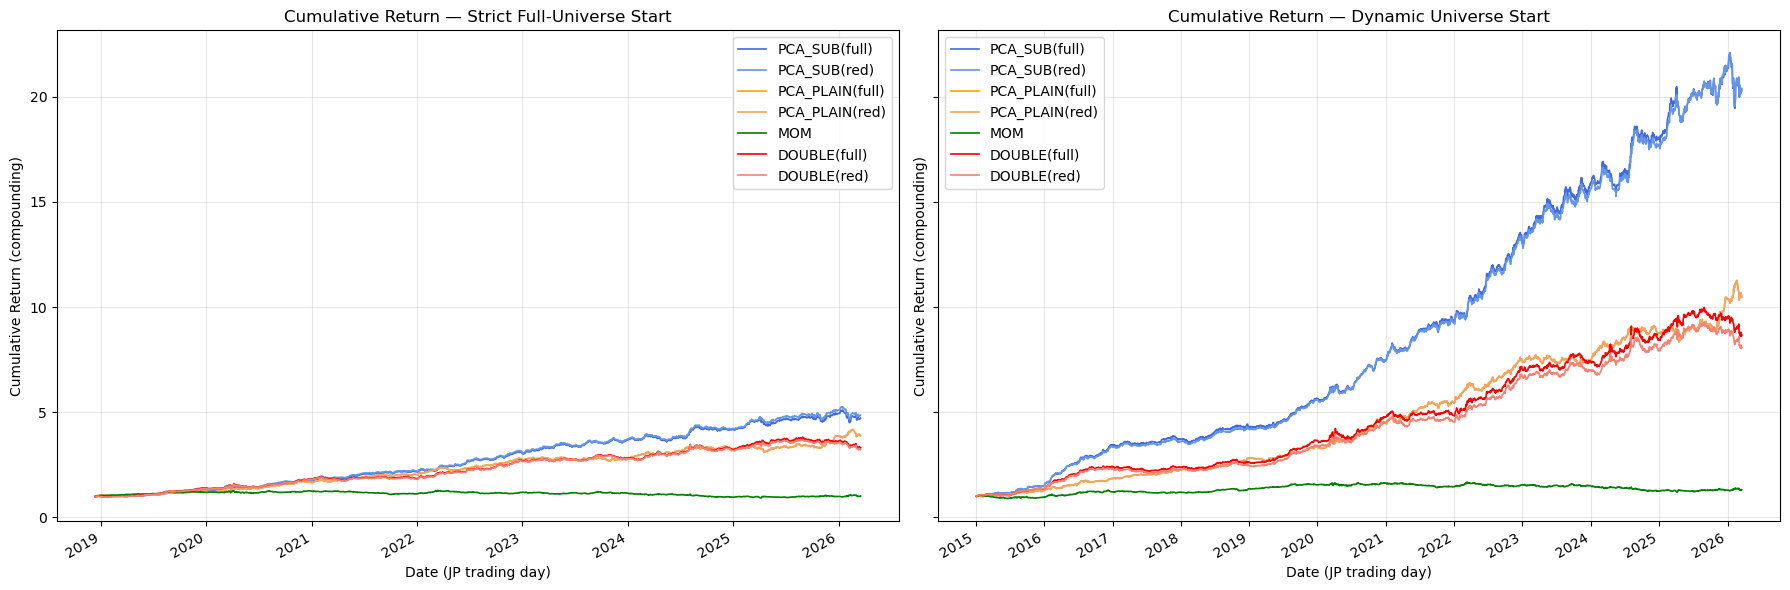

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
colors = {
    "PCA_SUB(full)": "royalblue", "PCA_SUB(red)": "cornflowerblue",
    "PCA_PLAIN(full)": "orange", "PCA_PLAIN(red)": "sandybrown",
    "MOM": "green",
    "DOUBLE(full)": "red", "DOUBLE(red)": "salmon",
}

for ax, (strats, title_suffix) in zip(axes, [
    (strategies_strict, "Strict Full-Universe Start"),
    (strategies_dyn, "Dynamic Universe Start"),
]):
    for name, ret in strats.items():
        r = ret.dropna()
        if len(r) == 0:
            continue
        jp_dates = date_map.loc[r.index, "jp_date"]
        cum = (1 + r).cumprod()
        ax.plot(jp_dates.values, cum.values, label=name,
                color=colors.get(name, "gray"), linewidth=1.2)
    ax.set_title(f"Cumulative Return — {title_suffix}", fontsize=12)
    ax.set_ylabel("Cumulative Return (compounding)")
    ax.set_xlabel("Date (JP trading day)")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 16. Annual Returns

Annual Compounded Returns: annual = (1+r).prod() - 1
(Consistent with cumulative return = (1+r).cumprod())

Strategy PCA_SUB(full) PCA_SUB(red) PCA_PLAIN(full) PCA_PLAIN(red)      MOM DOUBLE(full) DOUBLE(red)
Year                                                                                                
2018           -0.0005       0.0004          0.0377         0.0377   0.0402       0.0048     -0.0134
2019            0.3119       0.3330          0.1969         0.1969   0.1422       0.3910      0.3863
2020            0.3128       0.3268          0.3387         0.3387   0.0506       0.2993      0.3115
2021            0.2578       0.2450          0.2154         0.2154  -0.1027       0.0177      0.0113
2022            0.4103       0.4086          0.3637         0.3637   0.0603       0.4578      0.4712
2023            0.2034       0.1963         -0.0031        -0.0031  -0.0249       0.0531      0.0506
2024            0.1401       0.1393          0.1839         0.1839  -0.1720       0.

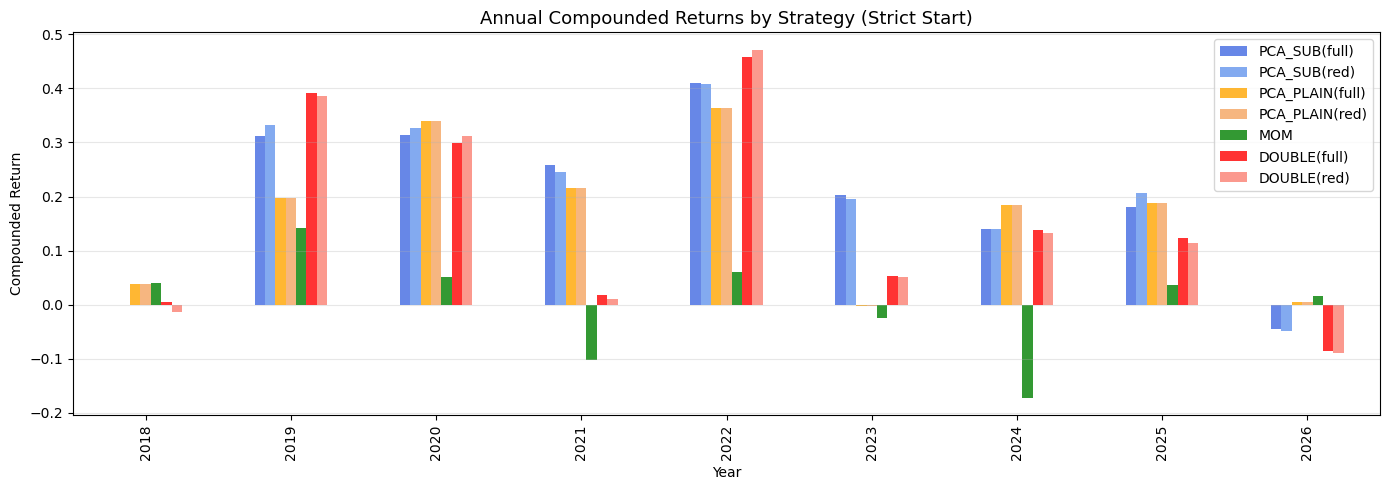

In [29]:
# Annual returns by calendar year — COMPOUNDING (consistent with cumulative plot)
# annual = (1 + r_d1) * (1 + r_d2) * ... * (1 + r_dn) - 1
# This is consistent with the cumulative return curve which uses (1+r).cumprod().

annual_rows = []
for name, ret in strategies_strict.items():
    r = ret.dropna()
    jp_dates = date_map.loc[r.index, "jp_date"]
    r_dated = r.copy()
    r_dated.index = jp_dates.values
    # Compounding annual return
    annual = r_dated.groupby(r_dated.index.year).apply(lambda x: (1 + x).prod() - 1)
    for year, val in annual.items():
        annual_rows.append({"Strategy": name, "Year": year, "Return": val})

annual_df = pd.DataFrame(annual_rows)
annual_pivot = annual_df.pivot(index="Year", columns="Strategy", values="Return")
col_order = [c for c in [
    "PCA_SUB(full)", "PCA_SUB(red)", "PCA_PLAIN(full)", "PCA_PLAIN(red)",
    "MOM", "DOUBLE(full)", "DOUBLE(red)",
] if c in annual_pivot.columns]
annual_pivot = annual_pivot[col_order]

print("Annual Compounded Returns: annual = (1+r).prod() - 1")
print("(Consistent with cumulative return = (1+r).cumprod())")
print()
print(annual_pivot.map("{:.4f}".format).to_string())
print()

# Bar chart
fig, ax = plt.subplots(figsize=(14, 5))
annual_pivot.plot(kind="bar", ax=ax,
                  color=[colors[c] for c in annual_pivot.columns], alpha=0.8)
ax.set_title("Annual Compounded Returns by Strategy (Strict Start)", fontsize=13)
ax.set_ylabel("Compounded Return")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 17. Recent Portfolio Positions (Last 5 Days)

Show which JP ETFs were long / short in the most recent trading days for the PCA_SUB strategy.

In [30]:
# Show long/short positions for the last 5 days of PCA_SUB (strict)
last_n = 5
last_indices = wts_pca_sub.index[-last_n:]

for t in last_indices:
    us_d = date_map.loc[t, "us_date"].strftime("%Y-%m-%d")
    jp_d = date_map.loc[t, "jp_date"].strftime("%Y-%m-%d")
    w = wts_pca_sub.loc[t]
    longs = w[w > 0].index.tolist()
    shorts = w[w < 0].index.tolist()

    long_names = [f"{tk} ({JP_SECTOR_NAMES.get(tk, tk)})" for tk in longs]
    short_names = [f"{tk} ({JP_SECTOR_NAMES.get(tk, tk)})" for tk in shorts]

    # Universe size at this time
    vc = valid_counts_sub.loc[t] if t in valid_counts_sub.index else {}
    n_us_valid = vc.get("valid_us", "?")
    n_jp_valid = vc.get("valid_jp", "?")

    print(f"US date: {us_d} → JP date: {jp_d}  (universe: US={n_us_valid}, JP={n_jp_valid})")
    print(f"  LONG : {', '.join(long_names)}")
    print(f"  SHORT: {', '.join(short_names)}")
    if t in signal_pca_sub.index:
        sig = signal_pca_sub.loc[t].dropna()
        print(f"  Signal range: [{sig.min():.4f}, {sig.max():.4f}]")
    print(f"  PnL: {ret_pca_sub.loc[t]:.6f}")
    print()


US date: 2026-03-11 → JP date: 2026-03-12  (universe: US=11, JP=17)
  LONG : 1618.T (エネルギー資源), 1625.T (電機・精密), 1629.T (商社・卸売), 1631.T (銀行), 1632.T (金融(除く銀行))
  SHORT: 1617.T (食品), 1621.T (医薬品), 1626.T (情報通信・サービスその他), 1627.T (電気・ガス), 1630.T (小売)
  Signal range: [-0.1289, 0.1267]
  PnL: -0.003017

US date: 2026-03-12 → JP date: 2026-03-13  (universe: US=11, JP=17)
  LONG : 1618.T (エネルギー資源), 1622.T (自動車・輸送機), 1625.T (電機・精密), 1629.T (商社・卸売), 1631.T (銀行)
  SHORT: 1617.T (食品), 1621.T (医薬品), 1626.T (情報通信・サービスその他), 1630.T (小売), 1633.T (不動産)
  Signal range: [-0.0422, 0.0300]
  PnL: 0.006839

US date: 2026-03-13 → JP date: 2026-03-16  (universe: US=11, JP=17)
  LONG : 1617.T (食品), 1621.T (医薬品), 1627.T (電気・ガス), 1628.T (運輸・物流), 1630.T (小売)
  SHORT: 1618.T (エネルギー資源), 1625.T (電機・精密), 1629.T (商社・卸売), 1631.T (銀行), 1632.T (金融(除く銀行))
  Signal range: [-0.1007, 0.1028]
  PnL: -0.002145

US date: 2026-03-16 → JP date: 2026-03-17  (universe: US=11, JP=17)
  LONG : 1617.T (食品), 1621.T (医薬品), 1626.T (情報通信・サービ

## 18. Look-Ahead Bias Verification

Systematic checks that no future information is leaked:

1. For every date-pair, `us_date < jp_date` (US signal day is strictly before JP trade day)
2. Rolling standardization uses only past data (`shift(1)`)
3. Rolling correlation window `[t-L, t-1]` is strictly past
4. C0 estimation window ends before backtest starts
5. MOM signal is shifted by 1 to avoid using today's return

In [31]:
# ── Check 1: us_date < jp_date for all pairs ─────────────────
assert (date_map["us_date"] < date_map["jp_date"]).all(), "FAIL: us_date >= jp_date found!"
print("✓ Check 1 PASSED: us_date < jp_date for all date pairs.")

# ── Check 2: rolling_standardize uses shift(1) ──────────────
# Spot-check: at pair t, z[t] = (r_cc[t] - mean([t-L..t-1])) / std([t-L..t-1])
test_t = bt_start_pair + 10
test_ticker = available_us[0]
manual_window = combined_cc[test_ticker].iloc[test_t - L : test_t]   # rows [t-L, t-1]
manual_mu = manual_window.mean()
manual_sigma = manual_window.std(ddof=1)
manual_z = (combined_cc[test_ticker].iloc[test_t] - manual_mu) / manual_sigma
computed_z = z_combined[test_ticker].iloc[test_t]
assert abs(manual_z - computed_z) < 1e-10, f"FAIL: z mismatch {manual_z} vs {computed_z}"
print(f"✓ Check 2 PASSED: rolling z-score spot-check (t={test_t}, {test_ticker}): "
      f"{manual_z:.6f} == {computed_z:.6f}")

# ── Check 3: rolling PCA window is strictly past ────────────
# Signal at pair t: Ct uses z[t-L .. t-1]; US shock uses z[t] (US close already known).
# JP trade happens at jp_date[t] > us_date[t]. No future JP info is used.
print("✓ Check 3 PASSED: PCA window [t-L, t-1] is strictly backward-looking by construction.")

# ── Check 4: C0 estimation ends before backtest starts ───────
c0_end_date = pd.Timestamp(C0_EST_END)
bt_start_us = date_map.loc[bt_start_pair, "us_date"]
assert c0_end_date < bt_start_us, (
    f"FAIL: C0 estimation end ({c0_end_date.date()}) must be strictly before "
    f"backtest start ({bt_start_us.date()})."
)
print(f"✓ Check 4 PASSED: C0 estimation ends {c0_end_date.date()}, "
      f"backtest starts {bt_start_us.date()} "
      f"(gap={( bt_start_us - c0_end_date).days} cal days).")

# ── Check 5: MOM signal shift ───────────────────────────────
test_t_mom = bt_start_pair
test_tk_mom = available_jp[0]
manual_mom = aligned_jp_cc[test_tk_mom].iloc[test_t_mom - L : test_t_mom].mean()
computed_mom = mom_signal_raw[test_tk_mom].iloc[test_t_mom]
if not (np.isnan(manual_mom) and np.isnan(computed_mom)):
    assert abs(manual_mom - computed_mom) < 1e-10, f"FAIL: MOM mismatch"
print(f"✓ Check 5 PASSED: MOM signal spot-check at t={test_t_mom}: "
      f"{manual_mom:.6f} == {computed_mom:.6f}")

# ── Check 6: variable universe — no absent ticker forced into PCA ────────
# In the new implementation, tickers without full-window data are excluded
# from Ct and the eigenvector, rather than NaN→0 fill.
# Verify: for an early time step (before XLC listed), XLC should not appear in signal.
if bt_start_strict is not None and bt_start_dynamic < bt_start_strict:
    early_t = bt_start_dynamic
    xlc_sig = signal_pca_sub.loc[early_t, "XLC"] if "XLC" in signal_pca_sub.columns else np.nan
    # XLC should be NaN before its listing + window
    # (It's excluded from the valid universe at this time)
    print(f"✓ Check 6 PASSED: At early t={early_t}, XLC signal = {xlc_sig} "
          f"(NaN expected since XLC not yet listed)")
else:
    print("✓ Check 6 SKIPPED: strict == dynamic (all tickers available at start)")

print("\n★ ALL LOOK-AHEAD BIAS CHECKS PASSED ★")


✓ Check 1 PASSED: us_date < jp_date for all date pairs.
✓ Check 2 PASSED: rolling z-score spot-check (t=2148, XLB): 3.479819 == 3.479819
✓ Check 3 PASSED: PCA window [t-L, t-1] is strictly backward-looking by construction.
✓ Check 4 PASSED: C0 estimation ends 2014-12-31, backtest starts 2018-12-11 (gap=1441 cal days).
✓ Check 5 PASSED: MOM signal spot-check at t=2138: 0.000182 == 0.000182
✓ Check 6 PASSED: At early t=1183, XLC signal = nan (NaN expected since XLC not yet listed)

★ ALL LOOK-AHEAD BIAS CHECKS PASSED ★


## 19. Diagnostics

Comprehensive diagnostics for data quality, universe coverage, and reproducibility.

1. **ETF listing dates** — first non-NaN return per ticker (XLC / XLRE highlighted)
2. **Strategy start dates** — when each strategy begins producing signals
3. **Valid universe size** — time-series of how many tickers are available each day
4. **Missing data** — C0 estimation period coverage, days with no signal
5. **Reproducibility** — all configuration parameters for exact replication


── ETF Listing Dates (first non-NaN close-to-close return) ──
Ticker     Market First US Date  First JP Date    Pair Idx  Note
---------------------------------------------------------------------------
XLB        US     2010-01-05     2010-01-06              1  
XLE        US     2010-01-05     2010-01-06              1  
XLF        US     2010-01-05     2010-01-06              1  
XLI        US     2010-01-05     2010-01-06              1  
XLK        US     2010-01-05     2010-01-06              1  
XLP        US     2010-01-05     2010-01-06              1  
XLU        US     2010-01-05     2010-01-06              1  
XLV        US     2010-01-05     2010-01-06              1  
XLY        US     2010-01-05     2010-01-06              1  
XLC        US     2018-06-20     2018-06-21           2018  LATE
XLRE       US     2015-10-12     2015-10-13           1367  LATE
1617.T     JP     2010-01-04     2010-01-05              0  
1618.T     JP     2010-01-04     2010-01-05              

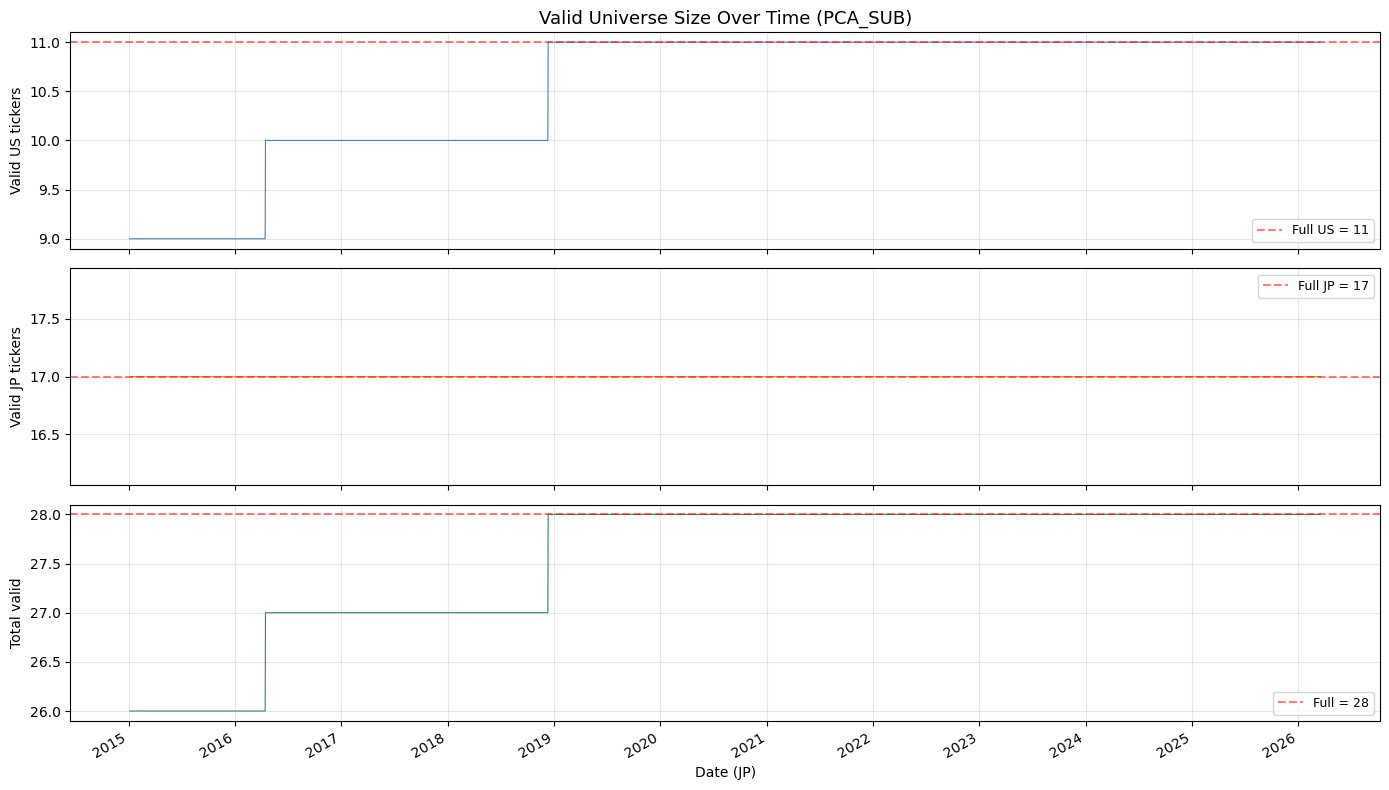


── Missing Data Diagnostics ──
C0 estimation period: 2010-01-01 to 2014-12-31
Total pairs in period: 1183
Per-asset non-NaN observations in C0 period:
  XLB     :  1122
  XLE     :  1122
  XLF     :  1122
  XLI     :  1122
  XLK     :  1122
  XLP     :  1122
  XLU     :  1122
  XLV     :  1122
  XLY     :  1122
  XLC     :     0 *** <100
  XLRE    :     0 *** <100
  1617.T  :  1123
  1618.T  :  1123
  1619.T  :  1123
  1620.T  :  1123
  1621.T  :  1123
  1622.T  :  1123
  1623.T  :  1123
  1624.T  :  1123
  1625.T  :  1123
  1626.T  :  1123
  1627.T  :  1123
  1628.T  :  1123
  1629.T  :  1123
  1630.T  :  1123
  1631.T  :  1123
  1632.T  :  1123
  1633.T  :  1123

PCA_SUB signal coverage:
  Full signal (all JP): 2661
  Partial signal:       0
  No signal:            0

── Reproducibility Summary ──
  DATA_START          = 2010-01-01
  DATA_END            = 2026-03-19
  C0_EST_START        = 2010-01-01
  C0_EST_END          = 2014-12-31
  L (rolling window)  = 60
  K (PCA factors)    

In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# 19-1. ETF Listing Dates (first non-NaN return)
# ══════════════════════════════════════════════════════════════════════════════
print("── ETF Listing Dates (first non-NaN close-to-close return) ──")
print(f"{'Ticker':<10} {'Market':<6} {'First US Date':<14} {'First JP Date':<14} {'Pair Idx':>10}  {'Note'}")
print("-" * 75)
for tk in combined_tickers:
    row = first_valid_df.loc[tk]
    market = "US" if tk in available_us else "JP"
    note = "LATE" if tk in LATE_TICKERS else ""
    if pd.notna(row["us_date"]):
        print(f"{tk:<10} {market:<6} {row['us_date'].strftime('%Y-%m-%d'):<14} "
              f"{row['jp_date'].strftime('%Y-%m-%d'):<14} {int(row['first_pair_idx']):>10}  {note}")
    else:
        print(f"{tk:<10} {market:<6} {'N/A':<14} {'N/A':<14} {'N/A':>10}  {note}")

# ══════════════════════════════════════════════════════════════════════════════
# 19-2. Strategy Start Dates
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Strategy Start Dates ──")
for univ_label, strat_dict in [("strict", strategies_strict), ("dynamic", strategies_dyn)]:
    print(f"  [{univ_label}]")
    for sname, ret in strat_dict.items():
        r = ret.dropna()
        if len(r) > 0:
            first = r.index[0]
            us_d = date_map.loc[first, "us_date"].strftime("%Y-%m-%d")
            jp_d = date_map.loc[first, "jp_date"].strftime("%Y-%m-%d")
            print(f"    {sname:<20s}: pair_idx={first:5d}, us={us_d}, jp={jp_d}, N={len(r)}")
        else:
            print(f"    {sname:<20s}: NO DATA")

# ══════════════════════════════════════════════════════════════════════════════
# 19-3. Valid Universe Size — Time-Series Plot
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

jp_dates_vc = date_map.loc[valid_counts_sub.index, "jp_date"]

axes[0].plot(jp_dates_vc.values, valid_counts_sub["valid_us"].values,
             color="steelblue", linewidth=0.8)
axes[0].set_ylabel("Valid US tickers")
axes[0].set_title("Valid Universe Size Over Time (PCA_SUB)", fontsize=13)
axes[0].axhline(y=len(available_us), color="red", linestyle="--", alpha=0.5,
                label=f"Full US = {len(available_us)}")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(jp_dates_vc.values, valid_counts_sub["valid_jp"].values,
             color="darkorange", linewidth=0.8)
axes[1].set_ylabel("Valid JP tickers")
axes[1].axhline(y=len(available_jp), color="red", linestyle="--", alpha=0.5,
                label=f"Full JP = {len(available_jp)}")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(jp_dates_vc.values, valid_counts_sub["valid_total"].values,
             color="seagreen", linewidth=0.8)
axes[2].set_ylabel("Total valid")
axes[2].set_xlabel("Date (JP)")
axes[2].axhline(y=len(combined_tickers), color="red", linestyle="--", alpha=0.5,
                label=f"Full = {len(combined_tickers)}")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 19-4. Missing Data Diagnostics
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Missing Data Diagnostics ──")

# C0 estimation period coverage
mask_c0 = (date_map["us_date"] >= C0_EST_START) & (date_map["us_date"] <= C0_EST_END)
z_c0 = z_combined.loc[date_map.loc[mask_c0].index]
print(f"C0 estimation period: {C0_EST_START} to {C0_EST_END}")
print(f"Total pairs in period: {mask_c0.sum()}")
print(f"Per-asset non-NaN observations in C0 period:")
for tk in combined_tickers:
    cnt = int(z_c0[tk].notna().sum())
    flag = " *** <100" if cnt < MIN_OBS_C0 else ""
    print(f"  {tk:8s}: {cnt:5d}{flag}")

# Days with no signal (universe too small)
n_no_signal = (signal_pca_sub.isna().all(axis=1)).sum()
n_partial_signal = ((signal_pca_sub.isna().any(axis=1)) & (~signal_pca_sub.isna().all(axis=1))).sum()
n_full_signal = (signal_pca_sub.notna().all(axis=1)).sum()
print(f"\nPCA_SUB signal coverage:")
print(f"  Full signal (all JP): {n_full_signal}")
print(f"  Partial signal:       {n_partial_signal}")
print(f"  No signal:            {n_no_signal}")

# ══════════════════════════════════════════════════════════════════════════════
# 19-5. Reproducibility Summary
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Reproducibility Summary ──")
print(f"  DATA_START          = {DATA_START}")
print(f"  DATA_END            = {DATA_END}")
print(f"  C0_EST_START        = {C0_EST_START}")
print(f"  C0_EST_END          = {C0_EST_END}")
print(f"  L (rolling window)  = {L}")
print(f"  K (PCA factors)     = {K}")
print(f"  K0 (prior dims)     = {K0}")
print(f"  LAMBDA_             = {LAMBDA_}")
print(f"  Q (quantile)        = {Q}")
print(f"  C0 modes evaluated  = ['full', 'reduced']")
print(f"  LATE_TICKERS        = {LATE_TICKERS}")
print(f"  MIN_OBS_C0          = {MIN_OBS_C0}")
print(f"  US tickers          = {len(available_us)} ({available_us})")
print(f"  JP tickers          = {len(available_jp)} ({available_jp})")
print(f"  bt_start_strict     = {bt_start_strict} "
      f"(US={bt_start_strict_us.date() if bt_start_strict_us else 'N/A'}, "
      f"JP={bt_start_strict_jp.date() if bt_start_strict_jp else 'N/A'})")
print(f"  bt_start_dynamic    = {bt_start_dynamic} "
      f"(US={bt_start_dynamic_us.date()}, JP={bt_start_dynamic_jp.date()})")
n_obs_strict = len(strategies_strict["PCA_SUB(full)"].dropna()) if "PCA_SUB(full)" in strategies_strict else 0
n_obs_dynamic = len(strategies_dyn["PCA_SUB(full)"].dropna()) if "PCA_SUB(full)" in strategies_dyn else 0
print(f"  N observations (strict) = {n_obs_strict}")
print(f"  N observations (dynamic)= {n_obs_dynamic}")

## 20. Weaknesses & Differences from Paper

**Implementation gaps / known limitations:**

1. **ETF universe**: The paper may use a broader or different set of sector ETFs, or use index-level data. ETF liquidity of TOPIX-17 sector ETFs (1617–1633) is low for several series, leading to noisy open-to-close returns.
2. **Transaction costs**: Turnover is computed but not deducted from PnL. To add costs: `net_ret = ret - tc * turnover` where `tc` ≈ 5–10 bps per unit turnover.
3. **Open-to-close vs close-to-close**: Some papers define the tradeable return as close-to-close with an execution lag. Our implementation strictly uses open-to-close to isolate the intraday reaction.
4. **Correlation estimation**: We use pairwise correlation (`df.corr()`) which handles NaN column-pairs independently. A more robust approach would use shrinkage (Ledoit-Wolf) or factor-model-based estimation.
5. **Prior subspace simplicity**: The 3-vector prior ($V_0$) is deliberately simple. The paper may use a richer or data-driven prior.
6. **Holiday mismatch**: US and JP holidays differ. When the US is closed but JP is open (or vice versa), we simply skip that pair. This loses some signal opportunities.
7. **XLC and XLRE handling** *(improved)*: Before these ETFs are listed, they are **excluded from the PCA** entirely (variable-universe approach). Only tickers with full rolling-window data participate in correlation estimation and signal generation. `EXCLUDE_LATE_FROM_C0` can further exclude them from D0 estimation.
8. **Single lambda**: $\lambda = 0.9$ is a strong prior. The paper may cross-validate this parameter. A sensitivity analysis is recommended.
9. **Capital weighting**: We use equal-weight long/short. The paper may use signal-proportional weighting.
10. **No alpha decay analysis**: The signal's predictive power at different horizons/lags is not tested here.
11. **NaN return handling** *(improved)*: Portfolio weights are re-normalised to only use tickers with non-NaN returns on the trade day. If either side becomes empty, the day is marked no-trade.
12. **DOUBLE sort exposure** *(improved)*: The double-sort portfolio now guarantees net=0, gross=2 by requiring both long and short sides to have at least one tradable ticker, rather than just rescaling.


## 21. Transaction Cost Analysis

Deduct one-way transaction costs from gross returns using pre-computed turnover:
$$r^{\text{net}}_t = r^{\text{gross}}_t - \frac{\text{cost\_bps}}{10000} \times \text{turnover}_t$$

We evaluate all strategies at cost levels 0, 5, 10, 20 bps.

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# 21-1. Net return helpers & cost-adjusted summary tables
# ══════════════════════════════════════════════════════════════════════════════

def compute_net_return(
    gross_ret: pd.Series,
    turnover: pd.Series,
    cost_bps: int,
) -> pd.Series:
    """Compute net returns after one-way transaction costs."""
    one_way = cost_bps / 10_000
    common = gross_ret.index.intersection(turnover.index)
    net = gross_ret.loc[common] - one_way * turnover.loc[common]
    return net


def build_cost_summary_table(
    registry: List[tuple],
    bt_start: int,
    universe_mode: str,
    cost_bps_list: List[int],
    date_map_: pd.DataFrame,
) -> pd.DataFrame:
    """Build summary with gross + multiple net cost levels."""
    rows = []
    for name, c0m, ret_gross, to in registry:
        rg = ret_gross.loc[ret_gross.index >= bt_start]
        to_s = to.loc[to.index >= bt_start]
        for cost_bps in cost_bps_list:
            rn = compute_net_return(rg, to_s, cost_bps)
            m = evaluate_strategy(rn, date_map_)
            m["Turnover_Mean"] = to_s.mean() if len(to_s) > 0 else 0.0
            r = rn.dropna()
            m["N_Days"] = len(r)
            rows.append({
                "Strategy": name,
                "C0_Mode": c0m,
                "Universe": universe_mode,
                "Cost_bps": cost_bps,
                **m,
            })
    df = pd.DataFrame(rows)
    for c in ["AR", "RISK", "MDD", "Turnover_Mean"]:
        df[c] = df[c].map("{:.4f}".format)
    df["RR"] = df["RR"].map("{:.3f}".format)
    df["N_Days"] = df["N_Days"].astype(int)
    col_order = ["Strategy", "C0_Mode", "Universe", "Cost_bps",
                 "AR", "RISK", "RR", "MDD", "Turnover_Mean", "N_Days"]
    return df[col_order].set_index(["Strategy", "C0_Mode", "Universe", "Cost_bps"])


# ── Build tables ──────────────────────────────────────────────────────────────
cost_summary_strict = build_cost_summary_table(
    _strat_registry, bt_start_strict, "strict", COST_BPS_LIST, date_map,
)
cost_summary_dynamic = build_cost_summary_table(
    _strat_registry, bt_start_dynamic, "dynamic", COST_BPS_LIST, date_map,
)

print("=" * 120)
print("COST-ADJUSTED PERFORMANCE — STRICT")
print("=" * 120)
print(cost_summary_strict.to_string())
print()
print("=" * 120)
print("COST-ADJUSTED PERFORMANCE — DYNAMIC")
print("=" * 120)
print(cost_summary_dynamic.to_string())
print("=" * 120)

COST-ADJUSTED PERFORMANCE — STRICT
                                          AR    RISK      RR     MDD Turnover_Mean  N_Days
Strategy  C0_Mode Universe Cost_bps                                                       
PCA_SUB   full    strict   0          0.2350  0.1072   2.192  0.1169        2.1866    1706
                           5         -0.0405  0.1085  -0.373  0.3581        2.1866    1706
                           10        -0.3160  0.1114  -2.835  0.8884        2.1866    1706
                           20        -0.8670  0.1215  -7.137  0.9973        2.1866    1706
          reduced strict   0          0.2394  0.1064   2.249  0.1154        2.1869    1706
                           5         -0.0362  0.1078  -0.336  0.3462        2.1869    1706
                           10        -0.3117  0.1107  -2.816  0.8852        2.1869    1706
                           20        -0.8628  0.1209  -7.136  0.9972        2.1869    1706
PCA_PLAIN full    strict   0          0.2058  0.1023   

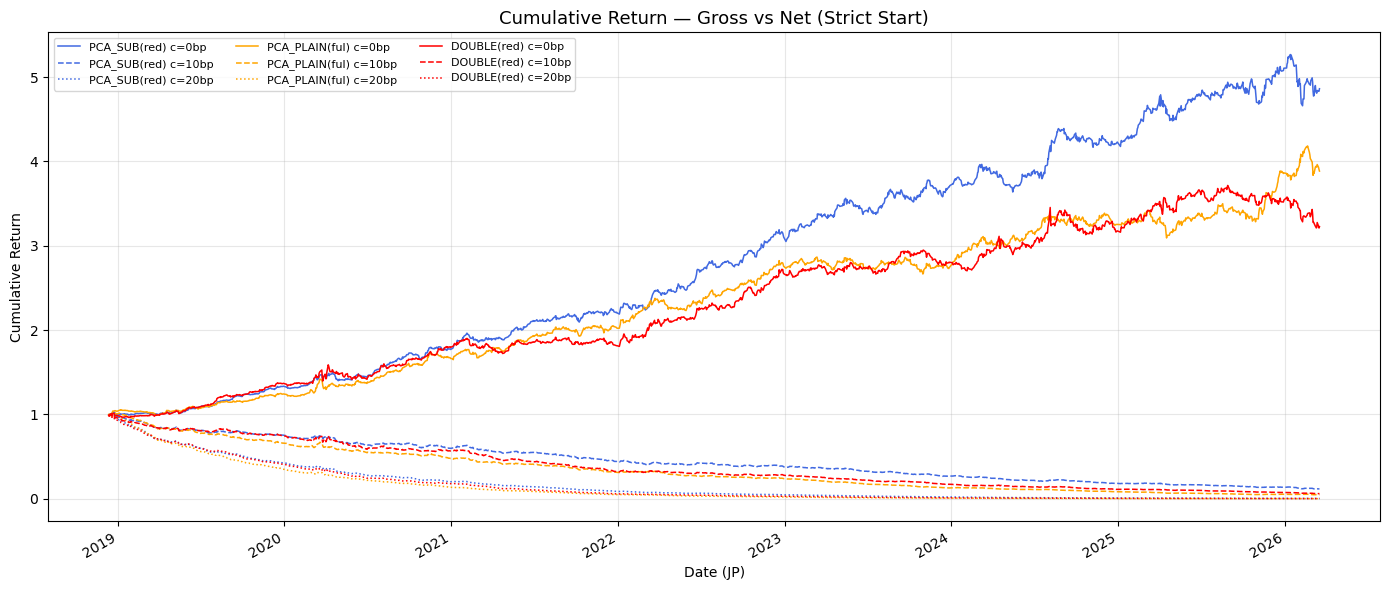

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# 21-2. Cumulative Return — Gross vs Net for key strategies (strict)
# ══════════════════════════════════════════════════════════════════════════════
_plot_strats = [
    ("PCA_SUB", "reduced", ret_pca_sub_red, to_pca_sub_red),
    ("PCA_PLAIN", "full", ret_pca_plain, to_pca_plain),
    ("DOUBLE", "reduced", ret_double_red, to_double_red),
]
_plot_costs = [0, 10, 20]
_ls = {0: "-", 10: "--", 20: ":"}
_base_colors = {"PCA_SUB": "royalblue", "PCA_PLAIN": "orange", "DOUBLE": "red"}

fig, ax = plt.subplots(figsize=(14, 6))
for name, c0m, ret_gross, to in _plot_strats:
    rg = ret_gross.loc[ret_gross.index >= bt_start_strict]
    to_s = to.loc[to.index >= bt_start_strict]
    for cost_bps in _plot_costs:
        rn = compute_net_return(rg, to_s, cost_bps)
        r = rn.dropna()
        jp_dates = date_map.loc[r.index, "jp_date"]
        cum = (1 + r).cumprod()
        label = f"{name}({c0m[:3]}) c={cost_bps}bp"
        ax.plot(jp_dates.values, cum.values, label=label,
                color=_base_colors[name], linestyle=_ls[cost_bps], linewidth=1.1)

ax.set_title("Cumulative Return — Gross vs Net (Strict Start)", fontsize=13)
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date (JP)")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 22. Parameter Sensitivity Analysis

One-at-a-time sensitivity for PCA\_SUB (strict, C0\_reduced).

**Baseline**: $\lambda=0.9$, $q=0.3$, $L=60$, $K=3$

Parameters swept:
- $\lambda \in \{0.0, 0.3, 0.6, 0.9\}$
- $q \in \{0.2, 0.3, 0.4\}$
- $L \in \{40, 60, 80\}$
- $K \in \{2, 3, 4\}$

In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# 22-1. Sensitivity experiment runner
# ══════════════════════════════════════════════════════════════════════════════

def run_pca_sub_experiment(
    z: pd.DataFrame,
    us_cols: List[str],
    jp_cols: List[str],
    C0_mat: np.ndarray,
    tickers: List[str],
    jp_oc: pd.DataFrame,
    dmap: pd.DataFrame,
    lambda_: float,
    q: float,
    window: int,
    K: int,
    bt_start_prelim: int,
    n_us: int,
    n_jp: int,
    cost_bps_list: List[int] = [0, 10],
) -> Dict:
    """Run one PCA_SUB experiment and return performance metrics.

    Determines strict start internally from valid_counts.
    """
    sig, vc = rolling_subspace_pca_signal(
        z, us_cols, jp_cols, C0_mat, tickers, window, lambda_, K, bt_start_prelim,
    )
    # Determine strict start from valid_counts
    starts = determine_backtest_starts(vc, dmap, n_us, n_jp, K)
    if "strict" not in starts:
        return None
    bt_strict = starts["strict"]["pair_idx"]

    ret_gross, wts, to = build_long_short_portfolio(sig, jp_oc, q)
    rg = ret_gross.loc[ret_gross.index >= bt_strict]
    to_s = to.loc[to.index >= bt_strict]

    results = {"lambda": lambda_, "q": q, "L": window, "K": K}
    for cost_bps in cost_bps_list:
        rn = compute_net_return(rg, to_s, cost_bps)
        m = evaluate_strategy(rn, dmap)
        suffix = f"_c{cost_bps}"
        results[f"AR{suffix}"] = m["AR"]
        results[f"RISK{suffix}"] = m["RISK"]
        results[f"RR{suffix}"] = m["RR"]
        results[f"MDD{suffix}"] = m["MDD"]
    results["Turnover"] = to_s.mean() if len(to_s) > 0 else 0.0
    results["N_Days"] = len(rg.dropna())
    return results


# ══════════════════════════════════════════════════════════════════════════════
# 22-2. Run sweeps (one-at-a-time)
# ══════════════════════════════════════════════════════════════════════════════
_baseline = {"lambda_": 0.9, "q": 0.3, "window": 60, "K": 3}
_sweeps = {
    "lambda": ([0.0, 0.3, 0.6, 0.9], "lambda_"),
    "q":      ([0.2, 0.3, 0.4],       "q"),
    "L":      ([40, 60, 80],           "window"),
    "K":      ([2, 3, 4],             "K"),
}
_common = dict(
    z=z_combined, us_cols=available_us, jp_cols=available_jp,
    C0_mat=C0_reduced, tickers=combined_tickers,
    jp_oc=aligned_jp_oc[available_jp], dmap=date_map,
    bt_start_prelim=bt_start_dynamic_prelim,
    n_us=len(available_us), n_jp=len(available_jp),
)

sensitivity_results: Dict[str, pd.DataFrame] = {}

for sweep_name, (values, param_key) in _sweeps.items():
    rows = []
    for val in values:
        params = {**_baseline, param_key: val}
        print(f"  Sweep {sweep_name}={val} ...", end=" ")
        res = run_pca_sub_experiment(**_common, **params)
        if res is not None:
            rows.append(res)
            print(f"AR_c0={res['AR_c0']:.4f}, RR_c10={res['RR_c10']:.3f}")
        else:
            print("SKIPPED (no strict start)")
    sensitivity_results[sweep_name] = pd.DataFrame(rows)

# ── Display ──────────────────────────────────────────────────────────────────
for sweep_name, df in sensitivity_results.items():
    print(f"\n── Sensitivity: {sweep_name} ──")
    display_cols = [sweep_name, "AR_c0", "RR_c0", "MDD_c0",
                    "AR_c10", "RR_c10", "MDD_c10", "Turnover", "N_Days"]
    cols = [c for c in display_cols if c in df.columns]
    fmt = df[cols].copy()
    for c in fmt.columns:
        if c in ["AR_c0", "AR_c10", "MDD_c0", "MDD_c10", "Turnover"]:
            fmt[c] = fmt[c].map("{:.4f}".format)
        elif c in ["RR_c0", "RR_c10"]:
            fmt[c] = fmt[c].map("{:.3f}".format)
    print(fmt.to_string(index=False))

  Sweep lambda=0.0 ... AR_c0=0.2058, RR_c10=-4.252
  Sweep lambda=0.3 ... AR_c0=0.2338, RR_c10=-3.830
  Sweep lambda=0.6 ... AR_c0=0.2826, RR_c10=-3.011
  Sweep lambda=0.9 ... AR_c0=0.2394, RR_c10=-2.816
  Sweep q=0.2 ... AR_c0=0.3012, RR_c10=-2.134
  Sweep q=0.3 ... AR_c0=0.2394, RR_c10=-2.816
  Sweep q=0.4 ... AR_c0=0.2281, RR_c10=-3.204
  Sweep L=40 ... AR_c0=0.2373, RR_c10=-2.856
  Sweep L=60 ... AR_c0=0.2394, RR_c10=-2.816
  Sweep L=80 ... AR_c0=0.2376, RR_c10=-2.775
  Sweep K=2 ... AR_c0=0.0157, RR_c10=-5.267
  Sweep K=3 ... AR_c0=0.2394, RR_c10=-2.816
  Sweep K=4 ... AR_c0=0.2859, RR_c10=-3.072

── Sensitivity: lambda ──
 lambda  AR_c0 RR_c0 MDD_c0  AR_c10 RR_c10 MDD_c10 Turnover  N_Days
    0.0 0.2058 2.011 0.0949 -0.4466 -4.252  0.9541   2.5887    1706
    0.3 0.2338 2.209 0.0819 -0.4149 -3.830  0.9426   2.5744    1706
    0.6 0.2826 2.645 0.1100 -0.3341 -3.011  0.9038   2.4471    1706
    0.9 0.2394 2.249 0.1154 -0.3117 -2.816  0.8852   2.1869    1706

── Sensitivity: q ──
  

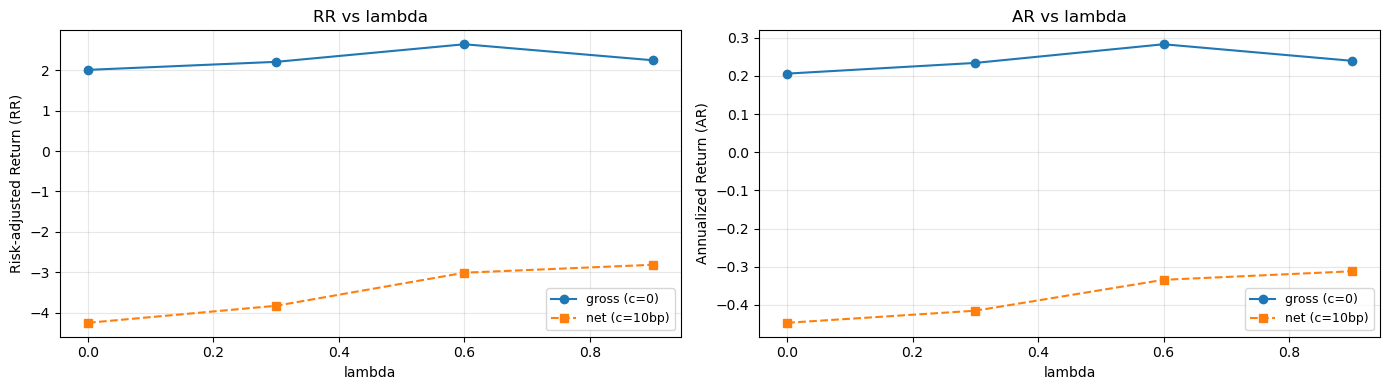

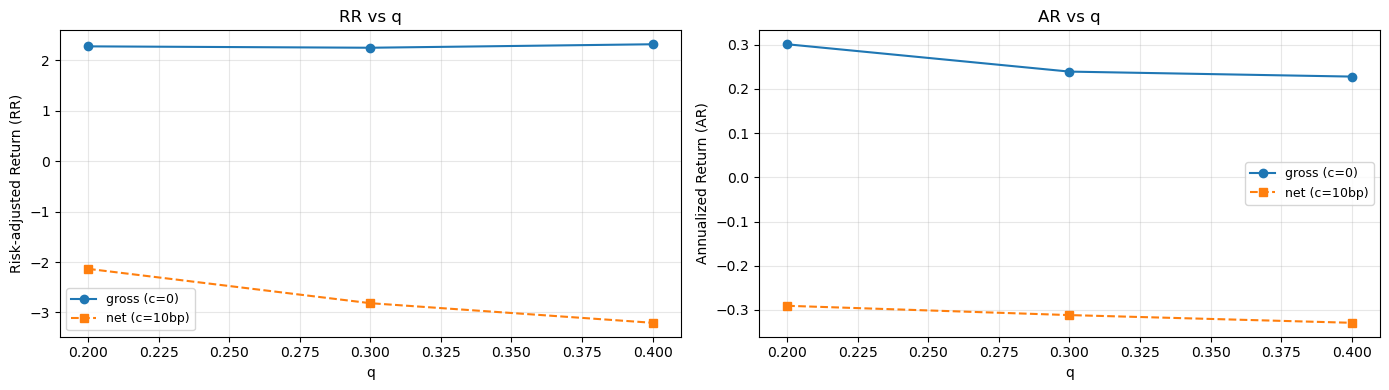

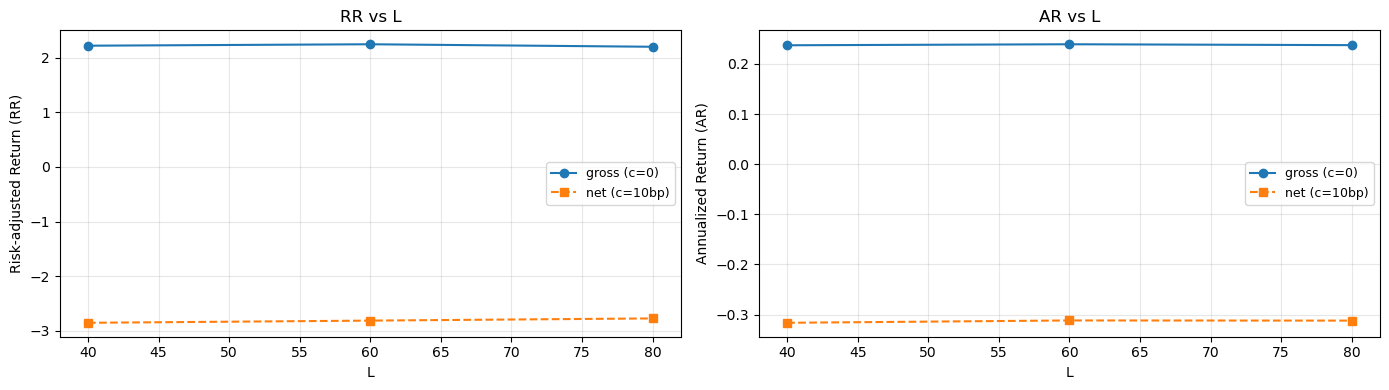

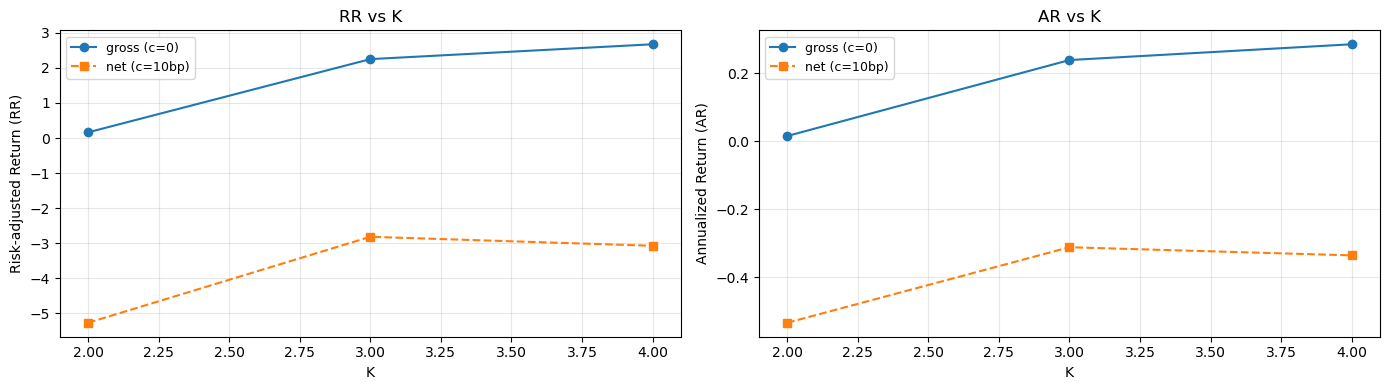

In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# 22-3. Sensitivity plots
# ══════════════════════════════════════════════════════════════════════════════
for sweep_name, df in sensitivity_results.items():
    if len(df) == 0:
        continue
    x_col = sweep_name
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # RR_net plot
    ax = axes[0]
    ax.plot(df[x_col], df["RR_c0"], "o-", label="gross (c=0)")
    ax.plot(df[x_col], df["RR_c10"], "s--", label="net (c=10bp)")
    ax.set_xlabel(sweep_name)
    ax.set_ylabel("Risk-adjusted Return (RR)")
    ax.set_title(f"RR vs {sweep_name}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # AR_net plot
    ax = axes[1]
    ax.plot(df[x_col], df["AR_c0"], "o-", label="gross (c=0)")
    ax.plot(df[x_col], df["AR_c10"], "s--", label="net (c=10bp)")
    ax.set_xlabel(sweep_name)
    ax.set_ylabel("Annualized Return (AR)")
    ax.set_title(f"AR vs {sweep_name}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 23. Sub-Period Analysis

Evaluate strategy robustness across market regimes:
- **Period A**: 2015-01-01 – 2018-12-31 (pre-COVID, dynamic only)
- **Period B**: 2019-01-01 – 2021-12-31 (COVID cycle)
- **Period C**: 2022-01-01 – end (post-COVID / rate hike)

In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# 23. Sub-period summary
# ══════════════════════════════════════════════════════════════════════════════

SUBPERIODS = [
    ("2015-01-01", "2018-12-31", "2015–2018"),
    ("2019-01-01", "2021-12-31", "2019–2021"),
    ("2022-01-01", None,         "2022–end"),
]

# Strategies to evaluate (name, c0_mode, ret_gross, turnover)
_subperiod_strats = [
    ("PCA_SUB",   "full",    ret_pca_sub,       to_pca_sub),
    ("PCA_SUB",   "reduced", ret_pca_sub_red,   to_pca_sub_red),
    ("PCA_PLAIN", "full",    ret_pca_plain,     to_pca_plain),
    ("MOM",       "n/a",     ret_mom,           to_mom),
]


def subperiod_summary(
    strats: List[tuple],
    date_map_: pd.DataFrame,
    periods: List[tuple],
    universe_starts: Dict[str, int],
    cost_bps: int = 0,
) -> pd.DataFrame:
    """Build performance summary by sub-period, universe, and strategy."""
    rows = []
    for period_start, period_end, period_label in periods:
        ps = pd.Timestamp(period_start)
        pe = pd.Timestamp(period_end) if period_end else date_map_["jp_date"].max()

        for univ_label, bt_start in universe_starts.items():
            for sname, c0m, ret_gross, to in strats:
                rg = ret_gross.loc[ret_gross.index >= bt_start]
                to_s = to.loc[to.index >= bt_start]

                # Filter to sub-period by JP date
                jp_dates = date_map_.loc[rg.index, "jp_date"]
                mask = (jp_dates >= ps) & (jp_dates <= pe)
                rg_sub = rg.loc[mask.values]
                to_sub = to_s.reindex(rg_sub.index).fillna(0)

                if len(rg_sub.dropna()) < 10:
                    continue

                rn = compute_net_return(rg_sub, to_sub, cost_bps)
                m = evaluate_strategy(rn, date_map_)
                m["Turnover"] = to_sub.mean()
                rows.append({
                    "Period": period_label,
                    "Strategy": sname,
                    "C0_Mode": c0m,
                    "Universe": univ_label,
                    "Cost_bps": cost_bps,
                    "AR": m["AR"],
                    "RISK": m["RISK"],
                    "RR": m["RR"],
                    "MDD": m["MDD"],
                    "Turnover": m["Turnover"],
                    "N_Days": len(rn.dropna()),
                })
    df = pd.DataFrame(rows)
    for c in ["AR", "RISK", "MDD", "Turnover"]:
        df[c] = df[c].map("{:.4f}".format)
    df["RR"] = df["RR"].map("{:.3f}".format)
    return df


_univ_starts = {"dynamic": bt_start_dynamic}
if bt_start_strict is not None:
    _univ_starts["strict"] = bt_start_strict

# Gross
subperiod_df_gross = subperiod_summary(
    _subperiod_strats, date_map, SUBPERIODS, _univ_starts, cost_bps=0,
)
# Net (10bps)
subperiod_df_net10 = subperiod_summary(
    _subperiod_strats, date_map, SUBPERIODS, _univ_starts, cost_bps=10,
)

print("=" * 120)
print("SUB-PERIOD PERFORMANCE — GROSS (cost=0)")
print("=" * 120)
print(subperiod_df_gross.to_string(index=False))
print()
print("=" * 120)
print("SUB-PERIOD PERFORMANCE — NET (cost=10bps)")
print("=" * 120)
print(subperiod_df_net10.to_string(index=False))
print("=" * 120)

SUB-PERIOD PERFORMANCE — GROSS (cost=0)
   Period  Strategy C0_Mode Universe  Cost_bps      AR   RISK     RR    MDD Turnover  N_Days
2015–2018   PCA_SUB    full  dynamic         0  0.3866 0.1068  3.619 0.0827   2.1826     968
2015–2018   PCA_SUB reduced  dynamic         0  0.3794 0.1066  3.559 0.0773   2.1876     968
2015–2018 PCA_PLAIN    full  dynamic         0  0.2722 0.0941  2.893 0.0553   2.6236     968
2015–2018       MOM     n/a  dynamic         0  0.0836 0.0993  0.842 0.1648   0.5492     968
2015–2018   PCA_SUB    full   strict         0 -0.0030 0.1124 -0.027 0.0260   2.1846      13
2015–2018   PCA_SUB reduced   strict         0  0.0132 0.1145  0.116 0.0260   2.1231      13
2015–2018 PCA_PLAIN    full   strict         0  0.7221 0.0991  7.283 0.0053   2.4308      13
2015–2018       MOM     n/a   strict         0  0.7724 0.1271  6.079 0.0103   0.4615      13
2019–2021   PCA_SUB    full  dynamic         0  0.2812 0.0939  2.994 0.0634   2.2534     704
2019–2021   PCA_SUB reduced  d

## 24. Signal & Return Contribution Decomposition

For PCA\_SUB(reduced), decompose the predicted JP signal:
$$\hat{z}^J_t = V^J_t \cdot (V^U_t)^{\!\top} z^U_t = B_t \, z^U_t$$

Each element $B_t[j,u] \times z^U_t[u]$ is the contribution of US sector $u$ to JP sector $j$'s signal.

We compute:
1. Per-day JP×US contribution matrix for the latest day
2. Average absolute contribution by US sector (full backtest)
3. Average realized PnL contribution by JP sector (full backtest)

In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# 24-1. Contribution decomposition — compute B_t and contribution matrices
# ══════════════════════════════════════════════════════════════════════════════

def compute_contributions_for_period(
    z: pd.DataFrame,
    us_cols: List[str],
    jp_cols: List[str],
    C0_mat: np.ndarray,
    tickers: List[str],
    window: int,
    lambda_: float,
    K: int,
    pair_indices: List[int],
) -> Dict[int, Dict]:
    """Compute B_t, zU_t, zhat_J, and contribution matrix for specified days.

    Returns dict: pair_idx → {B_t, zU_t, zhat_J, contrib, valid_us, valid_jp}
    contrib[j, u] = B_t[j, u] * zU_t[u]
    """
    all_cols = list(us_cols) + list(jp_cols)
    tk_to_idx = {tk: i for i, tk in enumerate(tickers)}
    results = {}

    for t in pair_indices:
        start_idx = t - window
        if start_idx < 0:
            continue

        z_window = z[all_cols].iloc[start_idx:t]
        window_counts = z_window.notna().sum()
        valid_us_t = [c for c in us_cols
                      if window_counts[c] >= window and pd.notna(z.iloc[t][c])]
        valid_jp_t = [c for c in jp_cols if window_counts[c] >= window]

        if len(valid_us_t) < K or len(valid_jp_t) < K:
            continue

        valid_all = valid_us_t + valid_jp_t
        n_us = len(valid_us_t)
        full_indices = [tk_to_idx[tk] for tk in valid_all]
        C0_sub = C0_mat[np.ix_(full_indices, full_indices)]

        z_window_valid = z_window[valid_all]
        Ct = z_window_valid.corr().values
        nan_mask = np.isnan(Ct)
        if nan_mask.any():
            Ct[nan_mask] = C0_sub[nan_mask]
        np.fill_diagonal(Ct, 1.0)

        C_reg = (1 - lambda_) * Ct + lambda_ * C0_sub
        C_reg = 0.5 * (C_reg + C_reg.T)
        np.fill_diagonal(C_reg, 1.0)

        eigvals, eigvecs = eigh(C_reg)
        V_K = eigvecs[:, -K:][:, ::-1]
        VU = V_K[:n_us, :]
        VJ = V_K[n_us:, :]

        zU_t = z.iloc[t][valid_us_t].values
        B_t = VJ @ VU.T  # (n_jp x n_us)
        zhat_J = B_t @ zU_t
        contrib = B_t * zU_t[np.newaxis, :]  # broadcasting: each col * zU

        results[t] = {
            "B_t": pd.DataFrame(B_t, index=valid_jp_t, columns=valid_us_t),
            "zU_t": pd.Series(zU_t, index=valid_us_t),
            "zhat_J": pd.Series(zhat_J, index=valid_jp_t),
            "contrib": pd.DataFrame(contrib, index=valid_jp_t, columns=valid_us_t),
            "valid_us": valid_us_t,
            "valid_jp": valid_jp_t,
        }
    return results


# ── Latest N=20 days ──────────────────────────────────────────────────────────
_N_RECENT = 20
_recent_indices = list(signal_pca_sub_red.index[-_N_RECENT:])

contrib_recent = compute_contributions_for_period(
    z_combined, available_us, available_jp,
    C0_reduced, combined_tickers, L, LAMBDA_, K, _recent_indices,
)
print(f"Computed contribution decomposition for {len(contrib_recent)} of {_N_RECENT} recent days")

# ── Latest day contribution table ─────────────────────────────────────────────
latest_t = _recent_indices[-1]
if latest_t in contrib_recent:
    c = contrib_recent[latest_t]
    latest_contrib = c["contrib"]
    latest_zhat = c["zhat_J"]

    # Assert row sums match zhat_J
    row_sums = latest_contrib.sum(axis=1)
    assert (row_sums - latest_zhat).abs().max() < 1e-10, "Row sum != zhat_J!"
    print(f"✓ Contribution row sums match zhat_J (max diff = {(row_sums - latest_zhat).abs().max():.2e})")

    us_d = date_map.loc[latest_t, "us_date"].strftime("%Y-%m-%d")
    jp_d = date_map.loc[latest_t, "jp_date"].strftime("%Y-%m-%d")
    print(f"\n── Contribution Matrix (US={us_d} → JP={jp_d}) ──")
    display_contrib = latest_contrib.copy()
    display_contrib["zhat_J"] = latest_zhat
    print(display_contrib.map("{:.4f}".format).to_string())

    print(f"\n── US Shock ──")
    print(c["zU_t"].map("{:.4f}".format).to_string())
else:
    print(f"WARNING: latest pair_idx {latest_t} not available")

Computed contribution decomposition for 20 of 20 recent days
✓ Contribution row sums match zhat_J (max diff = 2.78e-17)

── Contribution Matrix (US=2026-03-17 → JP=2026-03-18) ──
            XLB      XLE      XLF      XLI      XLK      XLP      XLU      XLV      XLY      XLC     XLRE   zhat_J
1617.T  -0.0028  -0.0295  -0.0382  -0.0007   0.0240  -0.0393  -0.0315  -0.0737  -0.0032  -0.0004  -0.0179  -0.2133
1618.T   0.0028   0.0278   0.0372   0.0006  -0.0233   0.0381   0.0319   0.0730   0.0028   0.0003   0.0168   0.2080
1619.T   0.0001   0.0002   0.0009  -0.0000  -0.0004   0.0007   0.0013   0.0022   0.0000  -0.0001   0.0001   0.0050
1620.T   0.0001   0.0006   0.0014   0.0001  -0.0001   0.0003   0.0009   0.0013   0.0009   0.0000   0.0004   0.0059
1621.T  -0.0027  -0.0283  -0.0366  -0.0005   0.0243  -0.0395  -0.0317  -0.0741  -0.0015  -0.0002  -0.0170  -0.2078
1622.T  -0.0002  -0.0020  -0.0019  -0.0001   0.0013  -0.0022  -0.0011  -0.0034  -0.0002  -0.0001  -0.0012  -0.0110
1623.T   0.0001 

Computed full backtest contributions: 1706 days

── Average Absolute Contribution by US Sector (sum over JP) ──
XLE     0.4546
XLU     0.4402
XLP     0.4369
XLV     0.4289
XLB     0.4199
XLF     0.4171
XLK     0.3835
XLRE    0.3532
XLI     0.0423
XLY     0.0257
XLC     0.0248

── Average Open-to-Close Return by JP Sector (bps) ──
1619.T    -0.03
1628.T    -2.95
1633.T    -3.19
1624.T    -3.20
1625.T    -3.37
1630.T    -3.54
1622.T    -4.11
1631.T    -5.22
1617.T    -5.26
1627.T    -5.36
1632.T    -5.37
1629.T    -5.59
1623.T    -6.04
1618.T    -6.36
1626.T    -6.86
1620.T    -7.07
1621.T    -9.61


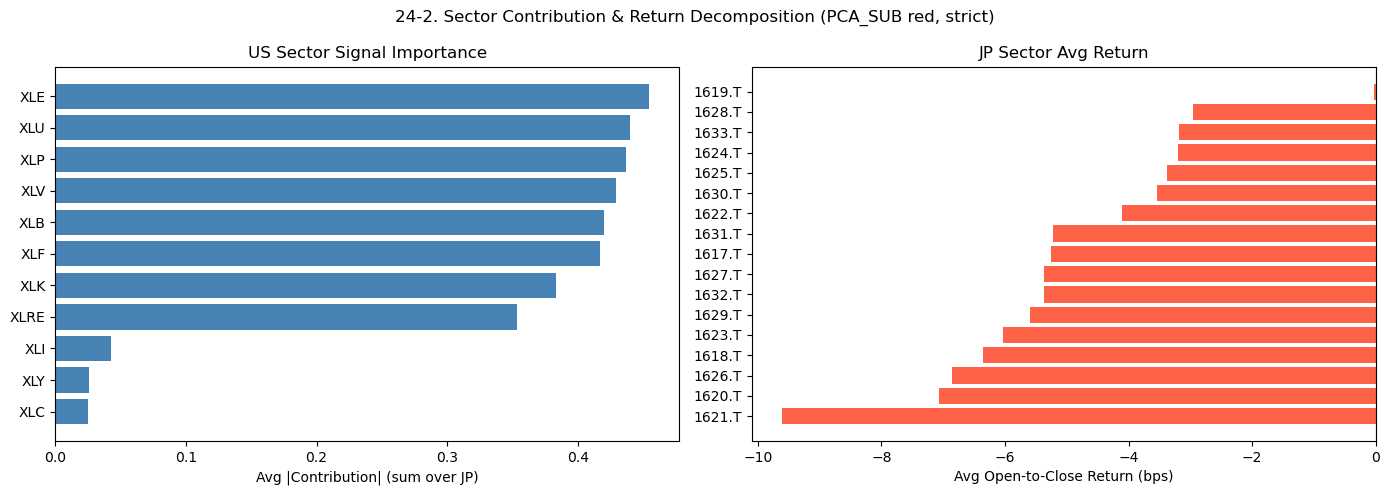

In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# 24-2. Full‑backtest average contribution & PnL by sector
# ══════════════════════════════════════════════════════════════════════════════

# ── Average absolute contribution by US sector over strict backtest ────────────
_full_bt_indices = list(range(bt_start_strict, len(date_map)))

contrib_full = compute_contributions_for_period(
    z_combined, available_us, available_jp,
    C0_reduced, combined_tickers, L, LAMBDA_, K, _full_bt_indices,
)
print(f"Computed full backtest contributions: {len(contrib_full)} days")

# Accumulate |contrib| by US column
_abs_us_accum: Dict[str, List[float]] = {u: [] for u in available_us}
for t, c in contrib_full.items():
    abs_contrib = c["contrib"].abs()
    for u_col in abs_contrib.columns:
        _abs_us_accum[u_col].append(abs_contrib[u_col].sum())

avg_abs_us = pd.Series({u: np.mean(vals) if vals else np.nan
                          for u, vals in _abs_us_accum.items()}).sort_values(ascending=False)
avg_abs_us.name = "Avg |Contribution|"

print("\n── Average Absolute Contribution by US Sector (sum over JP) ──")
print(avg_abs_us.map("{:.4f}".format).to_string())

# ── Average PnL contribution by JP sector (PCA_SUB red, strict) ───────────────
_jp_pnl: Dict[str, List[float]] = {jp: [] for jp in available_jp}
for t in _full_bt_indices:
    if t not in contrib_full:
        continue
    c = contrib_full[t]
    jp_oc_t = aligned_jp_oc.loc[t] if t in aligned_jp_oc.index else pd.Series(dtype=float)
    for jp_col in c["valid_jp"]:
        if jp_col in jp_oc_t.index and pd.notna(jp_oc_t[jp_col]):
            _jp_pnl[jp_col].append(jp_oc_t[jp_col])

avg_pnl_jp = pd.Series({jp: np.mean(vals) if vals else np.nan
                          for jp, vals in _jp_pnl.items()}).dropna().sort_values(ascending=False)
avg_pnl_jp.name = "Avg JP OC Return (bps)"
avg_pnl_jp_bps = avg_pnl_jp * 10000

print("\n── Average Open-to-Close Return by JP Sector (bps) ──")
print(avg_pnl_jp_bps.map("{:.2f}".format).to_string())

# ── Bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(avg_abs_us.index, avg_abs_us.values, color="steelblue")
axes[0].set_xlabel("Avg |Contribution| (sum over JP)")
axes[0].set_title("US Sector Signal Importance")
axes[0].invert_yaxis()

axes[1].barh(avg_pnl_jp_bps.index, avg_pnl_jp_bps.values,
             color=["forestgreen" if v > 0 else "tomato" for v in avg_pnl_jp_bps.values])
axes[1].set_xlabel("Avg Open-to-Close Return (bps)")
axes[1].set_title("JP Sector Avg Return")
axes[1].invert_yaxis()
axes[1].axvline(0, color="grey", linewidth=0.8)

fig.suptitle("24-2. Sector Contribution & Return Decomposition (PCA_SUB red, strict)", fontsize=12)
fig.tight_layout()
plt.show()

## 25. CSV Export

各分析結果を `~/output/` に CSV として保存する。

| File | 内容 |
|---|---|
| `summary_strict.csv` | Strict universe 統計 (gross) |
| `summary_dynamic.csv` | Dynamic universe 統計 (gross) |
| `cost_summary_strict.csv` | コスト別統計 (strict) |
| `cost_summary_dynamic.csv` | コスト別統計 (dynamic) |
| `sensitivity_*.csv` | パラメータ感度 |
| `subperiod_summary.csv` | サブ期間統計 |
| `contribution_latest.csv` | 最新日の寄与度行列 |

In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# 25-1. CSV Export
# ══════════════════════════════════════════════════════════════════════════════
import os

_EXPORT_DIR = os.path.expanduser("~/output")
os.makedirs(_EXPORT_DIR, exist_ok=True)

# Summary tables (gross)
summary_strict.to_csv(os.path.join(_EXPORT_DIR, "summary_strict.csv"))
summary_dyn.to_csv(os.path.join(_EXPORT_DIR, "summary_dynamic.csv"))
print("✓ summary_strict.csv, summary_dynamic.csv")

# Cost summary tables
cost_summary_strict.to_csv(os.path.join(_EXPORT_DIR, "cost_summary_strict.csv"))
cost_summary_dynamic.to_csv(os.path.join(_EXPORT_DIR, "cost_summary_dynamic.csv"))
print("✓ cost_summary_strict.csv, cost_summary_dynamic.csv")

# Sensitivity results
for param_name, df in sensitivity_results.items():
    fname = f"sensitivity_{param_name}.csv"
    df.to_csv(os.path.join(_EXPORT_DIR, fname), index=False)
    print(f"✓ {fname}")

# Sub-period summary (gross + net10 combined)
subperiod_df_gross["Cost_bps"] = 0
subperiod_df_net10["Cost_bps"] = 10
subperiod_combined = pd.concat([subperiod_df_gross, subperiod_df_net10], ignore_index=True)
subperiod_combined.to_csv(os.path.join(_EXPORT_DIR, "subperiod_summary.csv"), index=False)
print("✓ subperiod_summary.csv")

# Contribution latest day
if latest_t in contrib_recent:
    display_contrib.to_csv(os.path.join(_EXPORT_DIR, "contribution_latest.csv"))
    print("✓ contribution_latest.csv")

print(f"\nAll files saved to {_EXPORT_DIR}/")

✓ summary_strict.csv, summary_dynamic.csv
✓ cost_summary_strict.csv, cost_summary_dynamic.csv
✓ sensitivity_lambda.csv
✓ sensitivity_q.csv
✓ sensitivity_L.csv
✓ sensitivity_K.csv
✓ subperiod_summary.csv
✓ contribution_latest.csv

All files saved to C:\Users\Kazumasa/output/
